# Aim 1 — COMPASS on Parse 10M PBMC

**Question:** where in the structure of the cytokine response do individuals differ?
- **u**: shared response axis (overall direction of the response)
- **beta**: position of each cytokine along the axis
- **r**: cytokine-specific residual

**Steps**
0. Setup and a quick COMPASS sanity check
1. Configuration (check column names here)
2. Read data in chunks and build pseudobulks
3. Build response vectors per donor x cell type x cytokine
4. Decompose each donor
5. Compare donors
6. Leave-one-donor-out with component swapping (main result)
7. Interferon donor group vs the rest
8. Cytokine-family holdout
9. How many donors are needed?
10. Save results

## 0. Setup

Download the data yourself (about 10 million cells, very large h5ad):
- Parse Biosciences: https://www.parsebiosciences.com/datasets/10-million-human-pbmcs-in-a-single-experiment/
- Allen Immunology: https://apps.allenimmunology.org/aifi/resources/parse-10m-cytokines/

**Memory:** the file is opened in backed mode (not loaded into RAM), but the pseudobulk table takes a few GB. About 32 GB RAM is recommended.

In [3]:
# Run once
# !pip install anndata scanpy scipy pandas matplotlib seaborn
# !pip install git+https://github.com/rohitsinghlab/compass.git

In [4]:
import numpy as np, pandas as pd, scipy.sparse as sp
import anndata as ad
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr
from itertools import combinations
from compass import shared_axis, decompose, assemble, normalize

rng = np.random.default_rng(0)

### Quick COMPASS check (mini Aim 0)
If decomposition and reconstruction are correct, the error should be ~0 and r should be orthogonal to u.
For the full Aim 0, run the paper's scripts on Replogle/Nadig (in the COMPASS repo).

In [5]:
Z_test = rng.normal(size=(30, 200)) + 3 * rng.normal(size=200)
u_t = shared_axis(Z_test)
b_t, r_t = decompose(Z_test, u_t)
print("reconstruction error:", np.abs(assemble(b_t, r_t, u_t) - Z_test).max())
print("max |r . u|        :", np.abs(r_t @ u_t).max())

reconstruction error: 4.440892098500626e-16
max |r . u|        : 1.740274591099933e-14


## 1. Configuration
**Run the next cell first** to see column names and values, then fix the settings here.

In [6]:
DATA_PATH    = "data/parse10m/20260203_Parse_10M_PBMC_cytokines.h5ad"
DONOR_COL    = "donor"
CYTO_COL     = "cytokine"
CELLTYPE_COL = "cell_type"
CONTROL      = "PBS"

MIN_CELLS    = 10      # min cells per pseudobulk (same as Cytokine Dictionary)
MIN_CELLS_HALF = 5     # min cells in EACH random half (needed for the split-half ceiling)
MIN_CYTOKINES  = 20    # skip a cell type if fewer cytokines are shared by all donors
RESP_R         = 0.3   # responsive = donor-averaged half-A vs half-B correlation above this
MIN_DONOR_COVERAGE = 0.5  # per cell type, drop a donor that has < 50% of the cytokines of the best donor
MIN_DONORS     = 8     # skip a cell type if fewer donors remain

# Reference for responses (see section 3b): "inert" = mean of biologically inert cytokines, "PBS" = original control
REFERENCE      = "inert"
# Cytokines expected to have no specific effect on PBMCs; fixed a priori and removed from the main analysis
INERT          = ["Noggin", "Decorin", "PSPN", "GDNF", "Megalin", "PRL", "EPO", "TPO",
                  "FGF-beta", "EGF", "HGF", "VEGF", "IGF-1"]
MIN_INERT      = 5     # a donor needs at least this many inert cytokines to be re-referenced
NULL_Q         = 0.95  # responsive = larger than this quantile of inert-vs-inert differences
MIN_CPM      = 20      # gene must reach this mean CPM in control of that cell type
N_GENES      = 2000    # genes per cell type (by response variance on TRAIN donors)
CHUNK        = 200_000 # cells read per chunk
CELL_TYPES   = None    # None = auto (well-populated ones); or give a list

# "interferon group" from the Cytokine Dictionary (D1, D3, D4, D10). CHECK the names in your file.
IFN_GROUP    = ["Donor1", "Donor3", "Donor4", "Donor10"]

# Merge fine cell types into coarse ones (as in the Cytokine Dictionary).
# Types not listed keep their own label; rare types are dropped by the CELL_TYPES rule.
CELLTYPE_MERGE = {
    "CD4 Naive": "CD4 T", "CD4 Memory": "CD4 T",
    "CD8 Naive": "CD8 T", "CD8 Memory": "CD8 T",
    "B Naive": "B", "B Intermediate/Memory": "B",
}

In [7]:
adata = ad.read_h5ad(DATA_PATH, backed="r")
print(adata)
print(adata.obs.columns.tolist())
for col in [DONOR_COL, CYTO_COL, CELLTYPE_COL]:
    if col in adata.obs:
        print(f"\n{col}: {adata.obs[col].nunique()} values")
        print(adata.obs[col].value_counts().head(8))
print("\nX sample (should be raw integer counts):", adata.X[:5].toarray()[:, :10] if sp.issparse(adata.X[:5]) else adata.X[:5, :10])

AnnData object with n_obs × n_vars = 9697974 × 40352 backed at 'data/parse10m/20260203_Parse_10M_PBMC_cytokines.h5ad'
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type'
    var: 'n_cells'
    layers: None (.X)
['sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type']

donor: 12 values
donor
Donor1     1267690
Donor5     1066725
Donor12    1054708
Donor6      974030
Donor2      931569
Donor3      695158
Donor7      652386
Donor8      650974
Name: count, dtype: int64

cytokine: 91 values
cytokine
PBS           

## 2. Build pseudobulks
Cells are read in chunks and summed per **donor x cell type x cytokine x half**.
"Half" is a random 50/50 split of cells, used to build the split-half **noise ceiling**.

In [8]:
obs = adata.obs[[DONOR_COL, CELLTYPE_COL, CYTO_COL]].copy()
obs[CELLTYPE_COL] = obs[CELLTYPE_COL].astype(str).replace(CELLTYPE_MERGE)
for c in obs: obs[c] = obs[c].astype("category")

if CELL_TYPES is None:
    # keep cell types with a median of >= MIN_CELLS cells per donor x cytokine
    med = obs.groupby([CELLTYPE_COL, DONOR_COL, CYTO_COL], observed=True).size() \
             .groupby(level=0, observed=True).median()
    CELL_TYPES = med[med >= MIN_CELLS].index.tolist()
print("cell types:", CELL_TYPES)

keep = obs[CELLTYPE_COL].isin(CELL_TYPES).to_numpy()
half = rng.integers(0, 2, size=len(obs))

dc = obs[DONOR_COL].cat.codes.to_numpy().astype(np.int64)
tc = obs[CELLTYPE_COL].cat.codes.to_numpy().astype(np.int64)
kc = obs[CYTO_COL].cat.codes.to_numpy().astype(np.int64)
nD, nT, nK = [len(obs[c].cat.categories) for c in [DONOR_COL, CELLTYPE_COL, CYTO_COL]]
key = ((dc * nT + tc) * nK + kc) * 2 + half
key[~keep] = -1
uniq, grp = np.unique(key[keep], return_inverse=True)
group_of_cell = np.full(len(obs), -1); group_of_cell[keep] = grp
n_groups, n_genes_all = len(uniq), adata.n_vars
print(f"{n_groups} groups x {n_genes_all} genes  (~{n_groups*n_genes_all*4/1e9:.1f} GB float32)")

cell types: ['B', 'CD14 Mono', 'CD16 Mono', 'CD4 T', 'CD8 T', 'HSPC', 'MAIT', 'NK', 'NK CD56bright', 'NKT', 'Treg', 'cDC']
26162 groups x 40352 genes  (~4.2 GB float32)


In [9]:
import os, json

CACHE_DIR = "data/parse10m/cache"
os.makedirs(CACHE_DIR, exist_ok=True)
F_SUMS  = os.path.join(CACHE_DIR, "pb_sums.npy")
F_META  = os.path.join(CACHE_DIR, "pb_meta.pkl")
F_GENES = os.path.join(CACHE_DIR, "pb_genes.npy")
F_CFG   = os.path.join(CACHE_DIR, "pb_config.json")

# Settings that change the pseudobulk table; if any differ, the cache is rebuilt
cfg = {"data_path": DATA_PATH, "cell_types": sorted(map(str, CELL_TYPES)),
       "merge": CELLTYPE_MERGE, "n_groups": int(n_groups), "n_genes": int(n_genes_all)}

cache_ok = all(os.path.exists(f) for f in [F_SUMS, F_META, F_GENES, F_CFG])
if cache_ok:
    with open(F_CFG) as f:
        cache_ok = json.load(f) == cfg
    if not cache_ok:
        print("Settings changed since the cache was built -> recomputing")

if cache_ok:
    sums  = np.load(F_SUMS)
    meta  = pd.read_pickle(F_META)
    genes = np.load(F_GENES, allow_pickle=True)
    print(f"Loaded cached pseudobulks: {sums.shape[0]:,} groups x {sums.shape[1]:,} genes")
else:
    sums = np.zeros((n_groups, n_genes_all), dtype=np.float32)
    ncell = np.bincount(grp, minlength=n_groups)
    for start in range(0, adata.n_obs, CHUNK):
        end = min(start + CHUNK, adata.n_obs)
        g = group_of_cell[start:end]; m = g >= 0
        if not m.any(): continue
        X = adata.X[start:end]
        X = sp.csr_matrix(X) if not sp.issparse(X) else X.tocsr()
        rows = np.where(m)[0]
        G = sp.csr_matrix((np.ones(len(rows), np.float32), (g[m], rows)),
                          shape=(n_groups, end - start))
        P = G @ X
        sums += (P.toarray() if sp.issparse(P) else np.asarray(P)).astype(np.float32)
        print(f"\r{end:,}/{adata.n_obs:,} cells", end="")

    # Decode group keys back to labels
    h = uniq % 2; rest = uniq // 2
    k = rest % nK; rest //= nK; t = rest % nT; d = rest // nT
    meta = pd.DataFrame({
        "donor": obs[DONOR_COL].cat.categories[d],
        "cell_type": obs[CELLTYPE_COL].cat.categories[t],
        "cytokine": obs[CYTO_COL].cat.categories[k],
        "half": h, "n_cells": ncell})
    genes = np.asarray(adata.var_names)

    # Save everything for next time
    np.save(F_SUMS, sums)
    meta.to_pickle(F_META)
    np.save(F_GENES, genes)
    with open(F_CFG, "w") as f:
        json.dump(cfg, f)
    print(f"\nComputed and cached in {CACHE_DIR}")

print(meta.head())

Loaded cached pseudobulks: 26,162 groups x 40,352 genes
    donor cell_type cytokine  half  n_cells
0  Donor1         B   4-1BBL     0      356
1  Donor1         B   4-1BBL     1      342
2  Donor1         B     ADSF     0      310
3  Donor1         B     ADSF     1      287
4  Donor1         B    APRIL     0      127


## 3. Response vectors
For each donor x cell type x cytokine:

**response = log CPM(cytokine) - log CPM(PBS, same donor and cell type)**

Three versions are built: full, half A, and half B.

In [10]:
def logcpm(x):
    return np.log1p(x / max(x.sum(), 1) * 1e6)

meta["idx"] = np.arange(len(meta))
full = meta.groupby(["donor", "cell_type", "cytokine"], observed=True)

def build_tables(ct):
    # Returns responses[donor] = DataFrame (cytokine x gene) for full, halfA, halfB, and control mean CPM
    out = {"full": {}, "A": {}, "B": {}}
    ctrl_cpm = []
    sub = meta[meta.cell_type == ct]
    for donor, dsub in sub.groupby("donor", observed=True):
        def agg(rows):
            return sums[rows["idx"].to_numpy()].sum(0), rows["n_cells"].sum()
        pbs = dsub[dsub.cytokine == CONTROL]
        if pbs.n_cells.sum() < MIN_CELLS or pbs.groupby("half").n_cells.sum().reindex([0, 1]).fillna(0).min() < MIN_CELLS_HALF:
            continue
        ctl_full, _ = agg(pbs)
        ctl = {"full": logcpm(ctl_full),
               "A": logcpm(agg(pbs[pbs.half == 0])[0]),
               "B": logcpm(agg(pbs[pbs.half == 1])[0])}
        ctrl_cpm.append(ctl_full / max(ctl_full.sum(), 1) * 1e6)
        rows = {v: {} for v in out}
        for cyto, csub in dsub[dsub.cytokine != CONTROL].groupby("cytokine", observed=True):
            s, n = agg(csub)
            if n < MIN_CELLS: continue
            if csub.groupby("half").n_cells.sum().reindex([0, 1]).fillna(0).min() < MIN_CELLS_HALF: continue
            rows["full"][cyto] = logcpm(s) - ctl["full"]
            rows["A"][cyto] = logcpm(agg(csub[csub.half == 0])[0]) - ctl["A"]
            rows["B"][cyto] = logcpm(agg(csub[csub.half == 1])[0]) - ctl["B"]
        for v in out:
            out[v][donor] = pd.DataFrame(rows[v], index=genes).T
    expressed = np.mean(ctrl_cpm, axis=0) >= MIN_CPM
    return out, expressed

TABLES = {ct: build_tables(ct) for ct in CELL_TYPES}
for ct, (tb, ex) in TABLES.items():
    print(f"{ct}: {len(tb['full'])} donors, {ex.sum()} expressed genes")

B: 12 donors, 7260 expressed genes
CD14 Mono: 12 donors, 6810 expressed genes
CD16 Mono: 12 donors, 6694 expressed genes
CD4 T: 12 donors, 7102 expressed genes
CD8 T: 12 donors, 7239 expressed genes
HSPC: 12 donors, 7989 expressed genes
MAIT: 12 donors, 7156 expressed genes
NK: 12 donors, 6971 expressed genes
NK CD56bright: 12 donors, 7376 expressed genes
NKT: 12 donors, 7153 expressed genes
Treg: 12 donors, 7020 expressed genes
cDC: 12 donors, 6926 expressed genes


In [11]:
# Diagnostic: how many cytokines pass the cell-count filters, per donor and cell type.
# The analysis uses cytokines present in ALL donors, so one weak donor limits a cell type.
cov = pd.DataFrame({ct: {d: len(df) for d, df in tb["full"].items()} for ct, (tb, _) in TABLES.items()}).T
cov["shared_by_all"] = [len(set.intersection(*[set(df.index) for df in TABLES[ct][0]["full"].values()]))
                        for ct in cov.index]
cov

,Donor1,Donor10,Donor11,Donor12,Donor2,Donor3,Donor4,Donor5,Donor6,Donor7,Donor8,Donor9,shared_by_all
B,90,90,90,90,90,90,90,90,90,90,90,90,90
CD14 Mono,90,90,90,90,90,90,90,90,90,90,90,90,90
CD16 Mono,90,90,90,90,90,90,90,89,89,9,90,90,9
CD4 T,90,90,90,90,90,90,90,90,90,90,90,90,90
CD8 T,90,90,90,90,90,90,90,90,90,90,90,90,90
HSPC,75,14,89,74,10,35,62,80,40,41,21,85,0
MAIT,90,90,90,90,90,90,89,90,90,90,90,90,89
NK,90,90,90,90,90,90,90,90,90,90,90,90,90
NK CD56bright,90,90,90,90,90,90,90,90,90,90,90,90,90
NKT,83,79,90,89,89,90,21,89,90,87,90,89,19


### Gene and responsive-cytokine selection
- **Genes:** expressed in PBS, then the N_GENES genes with the highest response variance. In the transfer tests they are chosen from **training donors only**, to avoid leakage.
- **Responsive cytokine (inert reference):** its typical response size (median over donors) is larger than the NULL_Q quantile of differences *between inert cytokines themselves*. Inert-vs-inert differences show how large a response looks when there is no specific biology, so this is a direct null.
- **Responsive cytokine (PBS reference, fallback):** donor-averaged response reproducible between the two random halves of cells (correlation > RESP_R). Note: with PBS as reference this marks almost every cytokine as responsive, because of the shared non-specific shift described in section 3b.
- **Cell types** with fewer than MIN_CYTOKINES cytokines shared by all donors are skipped.

In [12]:
def common_cytokines(tb, donors):
    s = None
    for d in donors:
        s = set(tb[d].index) if s is None else s & set(tb[d].index)
    return sorted(s)

def select_genes(tb, donors, expressed, cytos):
    stack = np.vstack([tb[d].loc[cytos].to_numpy() for d in donors])
    var = np.where(expressed, stack.var(0), -np.inf)
    return np.argsort(var)[::-1][:min(N_GENES, expressed.sum())]

def responsive(tbs, donors, cytos, gidx):
    # With the inert reference: a cytokine is responsive if its typical (median over donors)
    # response size exceeds the NULL_Q quantile of inert-vs-other-inert differences.
    if "inert_null" in tbs:
        null = []
        for d in donors:
            I = tbs["inert_null"][d].to_numpy()[:, gidx]
            loo = I - (I.sum(0) - I) / (len(I) - 1)          # each inert vs mean of the others
            null.extend(np.linalg.norm(loo, axis=1))
        thr = np.quantile(null, NULL_Q)
        size = np.median([np.linalg.norm(tbs["full"][d].loc[cytos].to_numpy()[:, gidx], axis=1)
                          for d in donors], axis=0)
        return [c for c, x in zip(cytos, size) if x > thr]
    # Fallback (PBS reference): split-half reproducibility of the donor-averaged response
    A = np.mean([tbs["A"][d].loc[cytos].to_numpy()[:, gidx] for d in donors], 0)
    B = np.mean([tbs["B"][d].loc[cytos].to_numpy()[:, gidx] for d in donors], 0)
    A = A - A.mean(1, keepdims=True); B = B - B.mean(1, keepdims=True)
    r = (A * B).sum(1) / (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + 1e-12)
    return [c for c, x in zip(cytos, r) if x > RESP_R]

def good_donors(tb):
    # Per cell type, drop donors with < MIN_DONOR_COVERAGE of the best donor's cytokines
    all_donors = sorted(tb["full"])
    best = max(len(tb["full"][d]) for d in all_donors)
    return [d for d in all_donors if len(tb["full"][d]) >= MIN_DONOR_COVERAGE * best], all_donors

def Zmat(tb, d, cytos, gidx):
    return tb[d].loc[cytos].to_numpy()[:, gidx]

## 3b. Why PBS is not used as the reference (position / non-specific artifact)

**What we found (first run, PBS as reference):**
- Almost every cytokine (all 90 in B, CD4 T, CD8 T, NK, CD14 Mono) looked "responsive", which is biologically implausible.
- The plate layout is identical for all 12 donors, and **all six PBS wells are in plate row H (H7-H12)**, the edge row. Every cytokine always sits in the same well.
- Cytokines expected to be **biologically inert on PBMCs** (non-immune growth factors: Noggin, Decorin, PSPN, GDNF, Megalin, PRL, EPO, TPO, FGF-beta, EGF, HGF, VEGF, IGF-1) still showed a clear "response" vs PBS:

| cell type | inert_vs_median | cos_inert_u | inert_beta_frac |
|---|---|---|---|
| B | 0.47 | 0.77 | 0.71 |
| CD14 Mono | 0.50 | 0.69 | 0.59 |
| CD16 Mono | 0.51 | 0.77 | 0.85 |
| CD4 T | 0.50 | 0.76 | 0.69 |
| CD8 T | 0.49 | 0.79 | 0.76 |
| MAIT | 0.47 | 0.82 | 0.89 |
| NK | 0.47 | 0.79 | 0.84 |
| NK CD56bright | 0.49 | 0.85 | 0.98 |
| NKT | 0.51 | 0.85 | 1.00 |
| Treg | 0.49 | 0.83 | 0.99 |
| cDC | 0.51 | 0.74 | 0.79 |

- `inert_vs_median`: size of the inert "response" relative to a typical response (~half).
- `cos_inert_u`: alignment of the inert "response" with the shared axis u (0.7-0.85).
- `inert_beta_frac`: inert cytokines' position on the shared axis relative to the average cytokine (0.6-1.0).

**Interpretation:** with PBS as reference, a large part of the shared axis u is **not a cytokine-specific biological response** but a shift common to every non-PBS well. Two possible sources, not distinguishable here: (1) **well position** (PBS only on the plate edge), and (2) a **generic effect of adding any recombinant protein** (e.g. trace contaminants such as endotoxin). Because the layout is the same for all donors, this shift is also identical across donors and would falsely look like "structure shared across individuals".

**Solution:** use the **mean of the inert cytokines** as the reference instead of PBS. They sit in the same plate rows as the other cytokines and received a recombinant protein, so both technical sources cancel and only cytokine-specific responses remain. The inert list is fixed a priori and removed from the main analysis. Results should be reported with both references (sensitivity analysis: set `REFERENCE = "PBS"`).

**Link to secondary analysis (why average baselines work):** part of the strength of mean-based baselines on this dataset may come from this non-specific shift: any model that predicts the average response gets it for free.

The cell below recomputes the artifact check with PBS as reference, so it can be reproduced.

In [13]:
# Position-artifact check (PBS reference). Reproduces the table above.
ART = []
for ct, (tb, ex) in TABLES.items():
    donors, _ = good_donors(tb)
    if len(donors) < MIN_DONORS: continue
    cytos = common_cytokines(tb["full"], donors)
    inert = [c for c in INERT if c in cytos]
    if len(cytos) < MIN_CYTOKINES or len(inert) < MIN_INERT: continue
    gidx = select_genes(tb["full"], donors, ex, cytos)
    ii = [cytos.index(c) for c in inert]
    for d in donors:
        Z = Zmat(tb["full"], d, cytos, gidx)
        u = shared_axis(Z); beta, _ = decompose(Z, u)
        m_inert = Z[ii].mean(0)
        ART.append(dict(cell_type=ct, donor=d,
                        inert_vs_median=np.linalg.norm(m_inert) / np.median(np.linalg.norm(Z, axis=1)),
                        cos_inert_u=(m_inert @ u) / (np.linalg.norm(m_inert) + 1e-12),
                        inert_beta_frac=beta[ii].mean() / beta.mean()))
ART = pd.DataFrame(ART)
ART.groupby("cell_type")[["inert_vs_median", "cos_inert_u", "inert_beta_frac"]].median().round(2) if len(ART) else "no cell type had enough inert cytokines"

,inert_vs_median,cos_inert_u,inert_beta_frac
cell_type,,,
B,0.47,0.77,0.71
CD14 Mono,0.50,0.69,0.59
CD16 Mono,0.51,0.77,0.85
CD4 T,0.50,0.76,0.69
CD8 T,0.49,0.79,0.76
MAIT,0.47,0.82,0.89
NK,0.47,0.79,0.84
NK CD56bright,0.49,0.85,0.98
NKT,0.51,0.85,1.00


## 3c. Re-reference responses to the inert cytokines
For each donor and cell type: **response = response vs PBS - mean response of the inert cytokines** (done separately for full, half A and half B). Inert cytokines are removed from the cytokine list and kept only as the null for the responsive test. `TABLES_PBS` keeps the original PBS-referenced tables for the sensitivity analysis.

In [14]:
import copy
TABLES_PBS = TABLES

def rereference(tb):
    out = {v: {} for v in ["full", "A", "B"]}
    out["inert_null"] = {}
    for d in tb["full"]:
        inert = [c for c in INERT if all(c in tb[v][d].index for v in ["full", "A", "B"])]
        if len(inert) < MIN_INERT: continue                     # donor lacks enough inert cytokines
        for v in ["full", "A", "B"]:
            df = tb[v][d]
            out[v][d] = df.drop(index=inert) - df.loc[inert].mean(axis=0)
        out["inert_null"][d] = tb["full"][d].loc[inert]          # PBS-referenced inert rows, for the null
    return out

if REFERENCE == "inert":
    TABLES = {ct: (rereference(tb), ex) for ct, (tb, ex) in TABLES_PBS.items()}
    for ct, (tb, _) in TABLES.items():
        print(f"{ct}: {len(tb['full'])} donors re-referenced")
else:
    print("Using PBS as reference (sensitivity analysis)")

B: 12 donors re-referenced
CD14 Mono: 12 donors re-referenced
CD16 Mono: 11 donors re-referenced
CD4 T: 12 donors re-referenced
CD8 T: 12 donors re-referenced
HSPC: 9 donors re-referenced
MAIT: 12 donors re-referenced
NK: 12 donors re-referenced
NK CD56bright: 12 donors re-referenced
NKT: 11 donors re-referenced
Treg: 12 donors re-referenced
cDC: 12 donors re-referenced


## 4. Per-donor decomposition
Separately for each donor and cell type: **u = normalized mean response**, **beta = projection onto u**, **r = remainder**.
(Same order as the COMPASS README: decompose per context first, then average.)

In [15]:
def per_donor_decomp(tb, donors, cytos, gidx):
    comp = {}
    for d in donors:
        Z = Zmat(tb, d, cytos, gidx)
        u = shared_axis(Z)
        b, r = decompose(Z, u)
        comp[d] = {"u": u, "beta": pd.Series(b, index=cytos), "r": r, "Z": Z}
    return comp

DECOMP = {}
for ct, (tb, ex) in TABLES.items():
    donors, all_donors = good_donors(tb)
    dropped = sorted(set(all_donors) - set(donors))
    if len(donors) < MIN_DONORS:
        print(f"{ct}: only {len(donors)} donors with enough cells -> skipped"); continue
    if dropped:
        print(f"{ct}: dropped donors with too few cells: {dropped}")
    cytos = common_cytokines(tb["full"], donors)
    if len(cytos) < MIN_CYTOKINES:
        print(f"{ct}: only {len(cytos)} cytokines shared by all donors -> skipped"); continue
    gidx = select_genes(tb["full"], donors, ex, cytos)   # descriptive analysis: all donors
    resp = responsive(tb, donors, cytos, gidx)
    DECOMP[ct] = dict(donors=donors, cytos=cytos, gidx=gidx, resp=resp,
                      comp=per_donor_decomp(tb["full"], donors, cytos, gidx))
    print(f"{ct}: {len(cytos)} cytokines, {len(resp)} responsive")

if not DECOMP:
    raise RuntimeError("No cell type passed the filters; lower MIN_CYTOKINES or MIN_CELLS_HALF")

B: 77 cytokines, 14 responsive
CD14 Mono: 77 cytokines, 19 responsive
CD16 Mono: 76 cytokines, 14 responsive
CD4 T: 77 cytokines, 13 responsive
CD8 T: 77 cytokines, 10 responsive
HSPC: only 6 donors with enough cells -> skipped
MAIT: 77 cytokines, 0 responsive
NK: 77 cytokines, 8 responsive
NK CD56bright: 77 cytokines, 0 responsive
NKT: 62 cytokines, 0 responsive
Treg: 69 cytokines, 0 responsive
cDC: 56 cytokines, 3 responsive


In [16]:
for ct, D in DECOMP.items():
    print(f"{ct} ({len(D['resp'])}): {', '.join(sorted(D['resp']))}\n")

B (14): CD40L, IFN-beta, IFN-gamma, IFN-omega, IL-1-alpha, IL-1-beta, IL-10, IL-13, IL-15, IL-2, IL-21, IL-32-beta, IL-4, IL-7

CD14 Mono (19): C5a, GM-CSF, IFN-alpha1, IFN-beta, IFN-gamma, IFN-omega, IL-1-alpha, IL-1-beta, IL-10, IL-12, IL-13, IL-15, IL-2, IL-21, IL-3, IL-32-beta, IL-4, IL-7, M-CSF

CD16 Mono (14): GM-CSF, IFN-beta, IFN-gamma, IFN-omega, IL-1-beta, IL-10, IL-13, IL-15, IL-2, IL-21, IL-3, IL-4, IL-7, M-CSF

CD4 T (13): IFN-alpha1, IFN-beta, IFN-gamma, IFN-omega, IL-1-alpha, IL-1-beta, IL-10, IL-13, IL-15, IL-2, IL-32-beta, IL-4, IL-7

CD8 T (10): IFN-beta, IFN-gamma, IFN-omega, IL-1-alpha, IL-1-beta, IL-15, IL-2, IL-32-beta, IL-4, IL-7

MAIT (0): 

NK (8): IFN-beta, IFN-gamma, IFN-omega, IL-1-beta, IL-15, IL-2, IL-32-beta, IL-7

NK CD56bright (0): 

NKT (0): 

Treg (0): 

cDC (3): IFN-beta, IFN-omega, IL-32-beta



In [17]:
# Main analysis: keep cell types with enough responsive cytokines
MIN_RESPONSIVE = 8
DECOMP = {ct: D for ct, D in DECOMP.items() if len(D["resp"]) >= MIN_RESPONSIVE}
print("Main analysis cell types:", list(DECOMP))

Main analysis cell types: ['B', 'CD14 Mono', 'CD16 Mono', 'CD4 T', 'CD8 T', 'NK']


## 5. Compare donors
- **Direction (u):** cosine similarity between each pair of donors
- **Ordering (beta):** Spearman correlation over responsive cytokines
- **Specific part (r):** mean per-cytokine cosine similarity of r between two donors

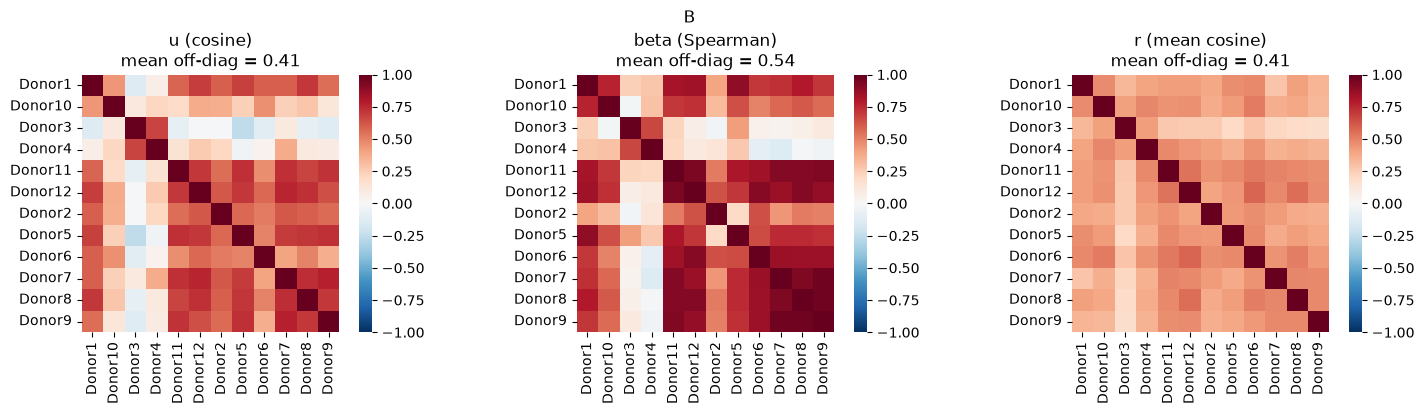

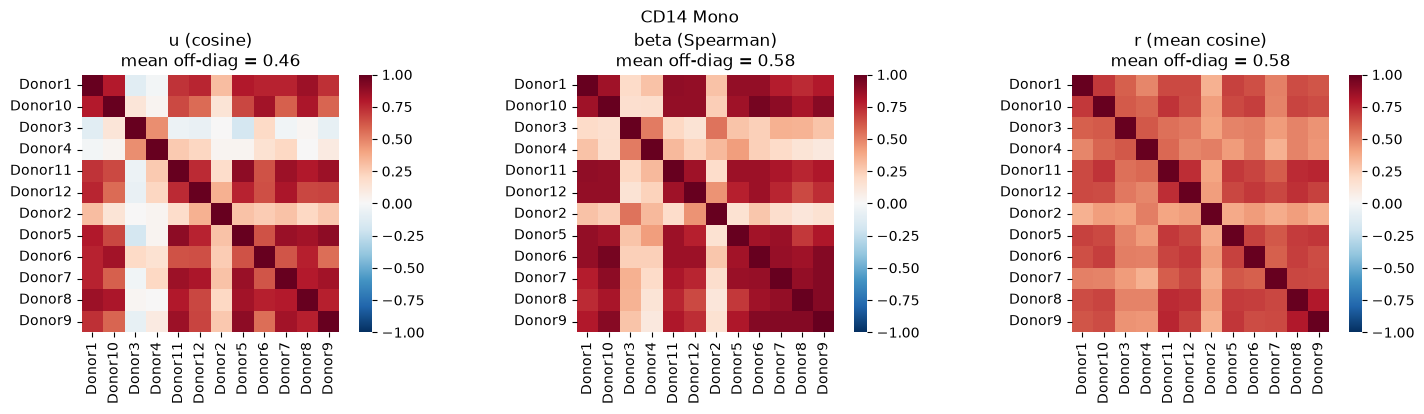

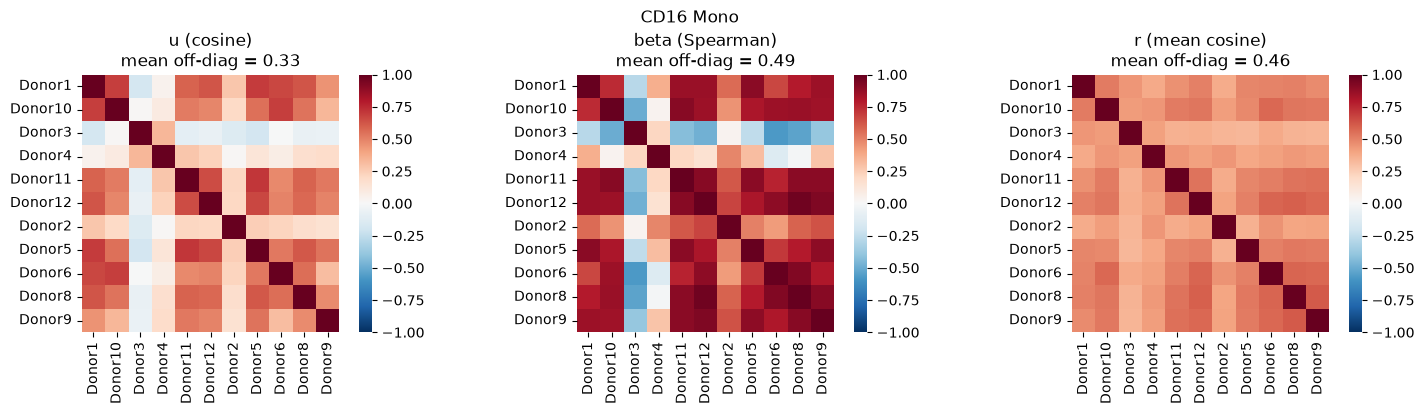

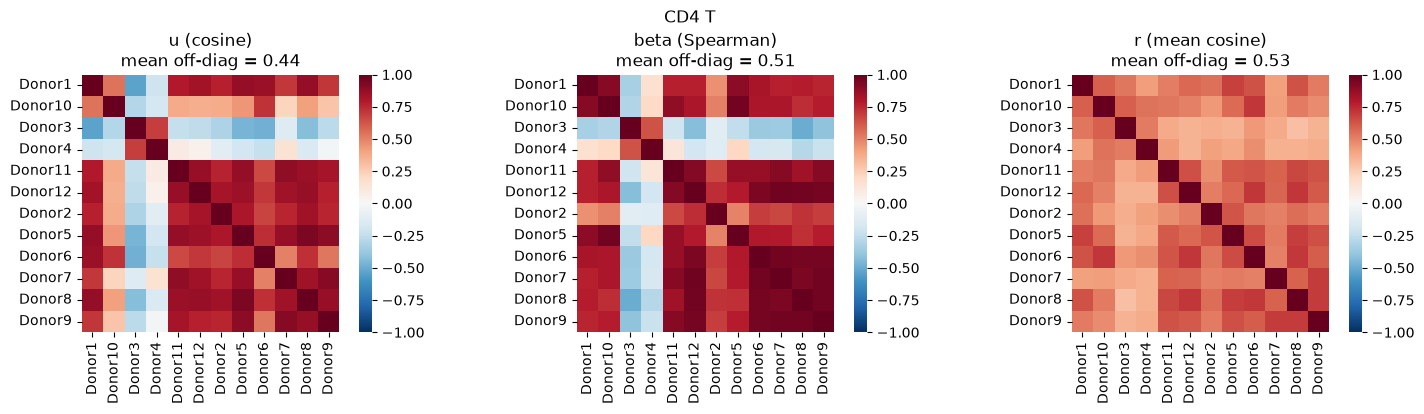

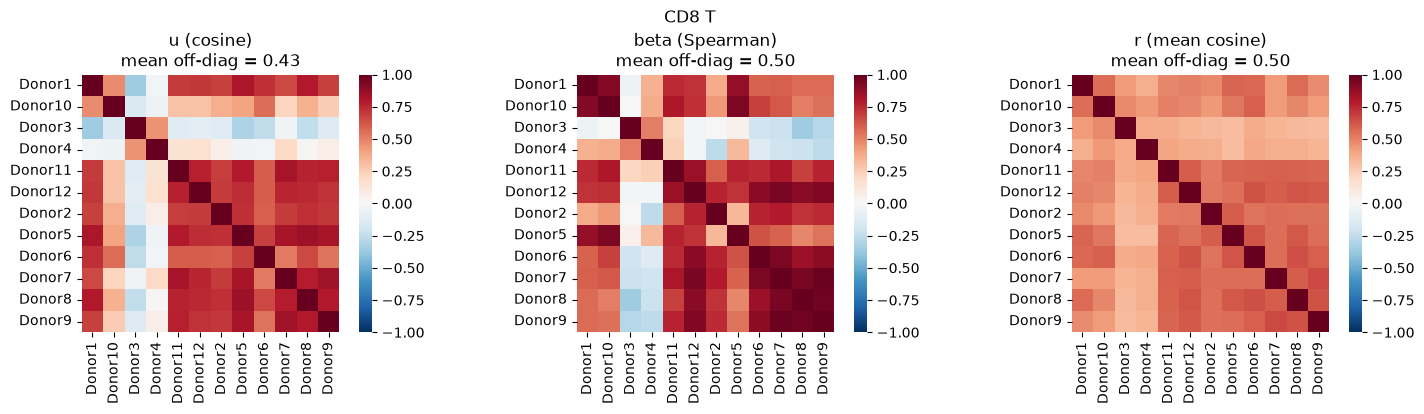

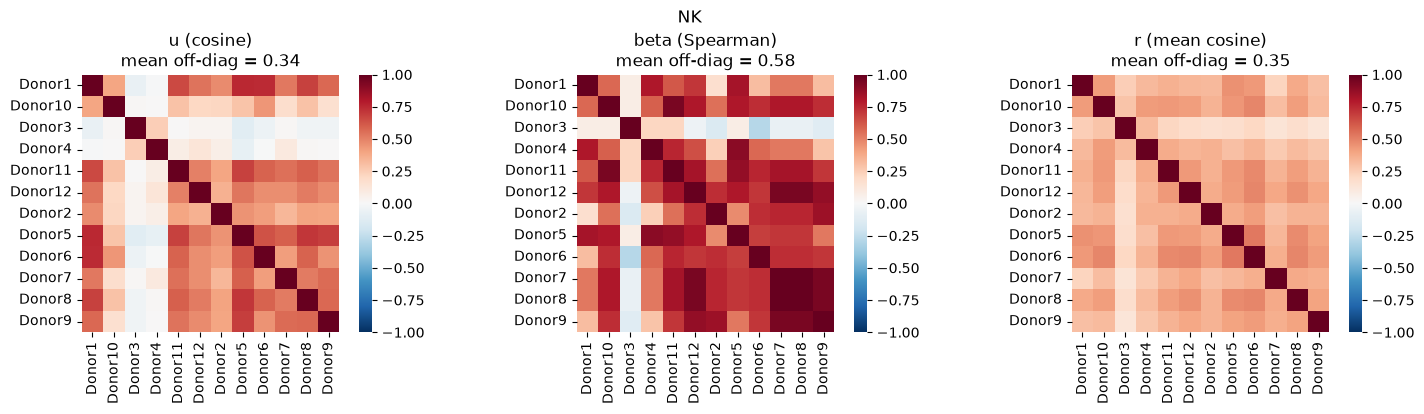

Saved to results/aim1


component,beta,r,u
cell_type,,,
B,0.539,0.410,0.407
CD14 Mono,0.575,0.580,0.462
CD16 Mono,0.488,0.464,0.330
CD4 T,0.510,0.529,0.440
CD8 T,0.496,0.496,0.431
NK,0.581,0.352,0.336


In [32]:
import os
RESULTS_DIR = "results/aim1"
os.makedirs(RESULTS_DIR, exist_ok=True)

def donor_similarity(D):
    donors, comp, resp = D["donors"], D["comp"], D["resp"]
    ri = [D["cytos"].index(c) for c in resp]
    n = len(donors); U = np.eye(n); B = np.eye(n); R = np.eye(n)
    for i, j in combinations(range(n), 2):
        a, b = comp[donors[i]], comp[donors[j]]
        U[i, j] = U[j, i] = a["u"] @ b["u"]
        B[i, j] = B[j, i] = spearmanr(a["beta"][resp], b["beta"][resp])[0]
        ra, rb = a["r"][ri], b["r"][ri]
        cos = (ra * rb).sum(1) / (np.linalg.norm(ra, axis=1) * np.linalg.norm(rb, axis=1) + 1e-12)
        R[i, j] = R[j, i] = cos.mean()
    return {k: pd.DataFrame(v, index=donors, columns=donors) for k, v in
            {"u (cosine)": U, "beta (Spearman)": B, "r (mean cosine)": R}.items()}

def order(donors):
    return [d for d in donors if d in IFN_GROUP] + [d for d in donors if d not in IFN_GROUP]

def safe(name):
    return name.replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")

SIM, SUMMARY = {}, []
for ct, D in DECOMP.items():
    SIM[ct] = donor_similarity(D)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, (name, M) in zip(ax, SIM[ct].items()):
        o = order(M.index.tolist())
        sns.heatmap(M.loc[o, o], ax=a, vmin=-1, vmax=1, cmap="RdBu_r", square=True)
        off = M.to_numpy()[np.triu_indices(len(M), 1)]
        a.set_title(f"{name}\nmean off-diag = {off.mean():.2f}")
        M.loc[o, o].to_csv(f"{RESULTS_DIR}/similarity_{safe(ct)}_{safe(name.split()[0])}.csv")
        SUMMARY.append(dict(cell_type=ct, component=name.split()[0], mean_offdiag=off.mean(),
                            n_donors=len(M), n_responsive=len(D["resp"])))
    fig.suptitle(ct); plt.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/similarity_{safe(ct)}.png", dpi=150, bbox_inches="tight")
    plt.show()

SUMMARY = pd.DataFrame(SUMMARY).pivot(index="cell_type", columns="component", values="mean_offdiag").round(3)
SUMMARY.to_csv(f"{RESULTS_DIR}/similarity_summary.csv")
print(f"Saved to {RESULTS_DIR}")
SUMMARY

In [17]:
# Within-donor reliability (ceiling): the same similarity measures between half A and half B of ONE donor.
# If between-donor similarity is close to this, donors do not really differ in that component.
REL = []
for ct, D in DECOMP.items():
    tb = TABLES[ct][0]
    resp, gidx = D["resp"], D["gidx"]
    ri = [D["cytos"].index(c) for c in resp]
    for d in D["donors"]:
        ZA = Zmat(tb["A"], d, D["cytos"], gidx); ZB = Zmat(tb["B"], d, D["cytos"], gidx)
        uA, uB = shared_axis(ZA), shared_axis(ZB)
        bA, rA = decompose(ZA, uA); bB, rB = decompose(ZB, uB)
        cos_r = ((rA[ri] * rB[ri]).sum(1) /
                 (np.linalg.norm(rA[ri], axis=1) * np.linalg.norm(rB[ri], axis=1) + 1e-12)).mean()
        REL.append(dict(cell_type=ct, donor=d, u=uA @ uB,
                        beta=spearmanr(bA[ri], bB[ri])[0], r=cos_r))
REL = pd.DataFrame(REL).groupby("cell_type")[["beta", "r", "u"]].mean().round(3)
REL.to_csv(f"{RESULTS_DIR}/within_donor_reliability.csv")

# Side by side: between donors vs within donor
cmp = pd.concat({"between": SUMMARY, "within": REL}, axis=1)
cmp.to_csv(f"{RESULTS_DIR}/between_vs_within.csv")
cmp

between               within              
component    beta      r      u   beta      r      u
cell_type                                           
B           0.539  0.410  0.407  0.944  0.555  0.640
CD14 Mono   0.575  0.580  0.462  0.987  0.883  0.909
CD16 Mono   0.488  0.464  0.330  0.904  0.556  0.509
CD4 T       0.510  0.529  0.440  0.988  0.781  0.862
CD8 T       0.496  0.496  0.431  0.975  0.610  0.664
NK          0.581  0.352  0.336  0.942  0.419  0.422

## 6. Leave-one-donor-out + component swapping (main result)

Learn from 11 donors, reconstruct the 12th. Four versions:

| version | u | beta | r |
|---|---|---|---|
| pop | population | population | population |
| own_u | **held-out donor** | population | population |
| own_beta | population | **held-out donor** | population |
| own_r | population | population | **held-out donor** |

The component whose swap gives the largest gain is **where that donor differs**.

**Scale:** everything is scored against half B.
- The held-out donor's own components are built from **half A only** (no leakage into half B)
- **Ceiling** = sqrt of the half A vs half B correlation (the best a noise-free prediction can reach against half B)
- **Floor** = population prediction with shuffled cytokine labels
- **gap filled** = (score - floor) / (ceiling - floor)

**Two metrics.** The correlation across genes measures only the *shape* of a response and is almost blind to its *size*. Since beta is exactly the size along the shared axis, the correlation metric underestimates differences in beta. We therefore also report **R2** (fraction of the response energy explained), which is sensitive to both shape and size.
- **R2 ceiling** = 1 - noise / ||half B||^2, where noise = ||half A - half B||^2 / 2 (A and B carry independent noise of equal size).
- **R2 floor** = population prediction with shuffled cytokine labels.
- `*_r2gap` = (score - floor) / (ceiling - floor), on the same scale as the correlation gaps.

In [25]:
def rowcorr(P, T):
    P = P - P.mean(1, keepdims=True); T = T - T.mean(1, keepdims=True)
    return (P * T).sum(1) / (np.linalg.norm(P, axis=1) * np.linalg.norm(T, axis=1) + 1e-12)

def r2(P, T):
    # Magnitude-sensitive score: fraction of the truth's energy explained (pooled over cytokines)
    return 1 - ((P - T) ** 2).sum() / ((T ** 2).sum() + 1e-12)

def population(comp, donors, cytos):
    u = normalize(np.mean([comp[d]["u"] for d in donors], 0))
    b = np.mean([comp[d]["beta"][cytos].to_numpy() for d in donors], 0)
    ri = np.mean([comp[d]["r"] for d in donors], 0)
    return u, b, ri

def evaluate(ct, train, test, n_perm=50, controls=False):
    tb, ex = TABLES[ct]
    cytos = common_cytokines(tb["full"], train + [test])
    gidx = select_genes(tb["full"], train, ex, cytos)          # genes from TRAIN only
    resp = responsive(tb, train, cytos, gidx)                    # responsive from TRAIN only
    if len(cytos) < MIN_CYTOKINES or len(resp) < 3: return None
    ri = [cytos.index(c) for c in resp]
    comp = per_donor_decomp(tb["full"], train, cytos, gidx)
    u_p, b_p, r_p = population(comp, train, cytos)

    Zt = Zmat(tb["A"], test, cytos, gidx)                       # own components from half A only (truth = half B, no leakage)
    u_t = shared_axis(Zt); b_t, r_t = decompose(Zt, u_t)
    truth = Zmat(tb["B"], test, cytos, gidx)[ri]
    halfA = Zmat(tb["A"], test, cytos, gidx)[ri]

    preds = {"pop": assemble(b_p, r_p, u_p),
             "own_u": assemble(b_p, r_p, u_t),
             "own_beta": assemble(b_t, r_p, u_p),
             "own_r": assemble(b_p, r_t, u_p)}
    # --- Metric 1: correlation across genes (shape only; insensitive to response size)
    res = {k: rowcorr(v[ri], truth).mean() for k, v in preds.items()}
    # half-vs-half correlation estimates reliability of one half; a noise-free prediction
    # can reach at most sqrt(reliability) against half B
    res["ceiling"] = np.sqrt(np.clip(rowcorr(halfA, truth), 0, None)).mean()
    P = preds["pop"][ri]
    perms = [rng.permutation(len(ri)) for _ in range(n_perm)]
    res["floor"] = np.mean([rowcorr(P[p], truth).mean() for p in perms])
    for k in ["pop", "own_u", "own_beta", "own_r"]:
        res[k + "_gap"] = (res[k] - res["floor"]) / (res["ceiling"] - res["floor"] + 1e-12)

    # --- Metric 2: R2 (sensitive to both shape AND size, so it sees differences in beta)
    for k, v in preds.items():
        res[k + "_r2"] = r2(v[ri], truth)
    # Noise energy of one half: A and B carry independent noise of equal size, so
    # ||A - B||^2 ~ 2 x noise. A noise-free prediction can explain at most 1 - noise / ||B||^2.
    noise = ((halfA - truth) ** 2).sum() / 2
    res["ceiling_r2"] = 1 - noise / ((truth ** 2).sum() + 1e-12)
    res["floor_r2"] = np.mean([r2(P[p], truth) for p in perms])
    for k in ["pop", "own_u", "own_beta", "own_r"]:
        res[k + "_r2gap"] = (res[k + "_r2"] - res["floor_r2"]) / (res["ceiling_r2"] - res["floor_r2"] + 1e-12)
    # --- Control 1: swap in ANOTHER training donor's component, estimated from half A like the
    # held-out donor's. Same noise level, but not this donor's biology. Averaged over all others.
    if controls:
        acc = {}
        for o in train:
            ZoA = Zmat(tb["A"], o, cytos, gidx)
            u_o = shared_axis(ZoA); b_o, r_o = decompose(ZoA, u_o)
            po = {"other_u": assemble(b_p, r_p, u_o),
                  "other_beta": assemble(b_o, r_p, u_p),
                  "other_r": assemble(b_p, r_o, u_p)}
            for k, v in po.items():
                acc.setdefault(k, []).append(rowcorr(v[ri], truth).mean())
                acc.setdefault(k + "_r2", []).append(r2(v[ri], truth))
        for k, v in acc.items():
            res[k] = np.mean(v)
        for k in ["other_u", "other_beta", "other_r"]:
            res[k + "_gap"] = (res[k] - res["floor"]) / (res["ceiling"] - res["floor"] + 1e-12)
            res[k + "_r2gap"] = (res[k + "_r2"] - res["floor_r2"]) / (res["ceiling_r2"] - res["floor_r2"] + 1e-12)

    res.update(cell_type=ct, test=test, n_resp=len(resp), u_cos=u_p @ u_t,
               beta_rho=spearmanr(b_p[ri], b_t[ri])[0])
    return res

LODO = []
for ct, D in DECOMP.items():
    for test in D["donors"]:
        train = [d for d in D["donors"] if d != test]
        r = evaluate(ct, train, test, controls=True)
        if r: LODO.append(r)
LODO = pd.DataFrame(LODO)
LODO["group"] = np.where(LODO.test.isin(IFN_GROUP), "IFN", "non-IFN")
print("Correlation-based (shape):")
display(LODO.groupby("cell_type")[["pop_gap", "own_u_gap", "own_beta_gap", "own_r_gap", "u_cos", "beta_rho"]].mean().round(3))
print("R2-based (shape + size):")
display(LODO.groupby("cell_type")[["ceiling_r2", "pop_r2gap", "own_u_r2gap", "own_beta_r2gap", "own_r_r2gap"]].mean().round(3))

Correlation-based (shape):


,pop_gap,own_u_gap,own_beta_gap,own_r_gap,u_cos,beta_rho
cell_type,,,,,,
B,0.652,0.638,0.688,0.648,0.548,0.714
CD14 Mono,0.724,0.777,0.726,0.821,0.649,0.761
CD16 Mono,0.717,0.678,0.729,0.674,0.461,0.704
CD4 T,0.679,0.712,0.726,0.765,0.629,0.687
CD8 T,0.715,0.672,0.742,0.683,0.598,0.662
NK,0.647,0.441,0.653,0.433,0.474,0.759


R2-based (shape + size):


,ceiling_r2,pop_r2gap,own_u_r2gap,own_beta_r2gap,own_r_r2gap
cell_type,,,,,
B,0.778,0.629,0.631,0.729,0.533
CD14 Mono,0.964,0.731,0.788,0.770,0.792
CD16 Mono,0.684,0.688,0.666,0.752,0.492
CD4 T,0.940,0.713,0.745,0.793,0.717
CD8 T,0.828,0.692,0.669,0.769,0.552
NK,0.647,0.638,0.490,0.713,0.083


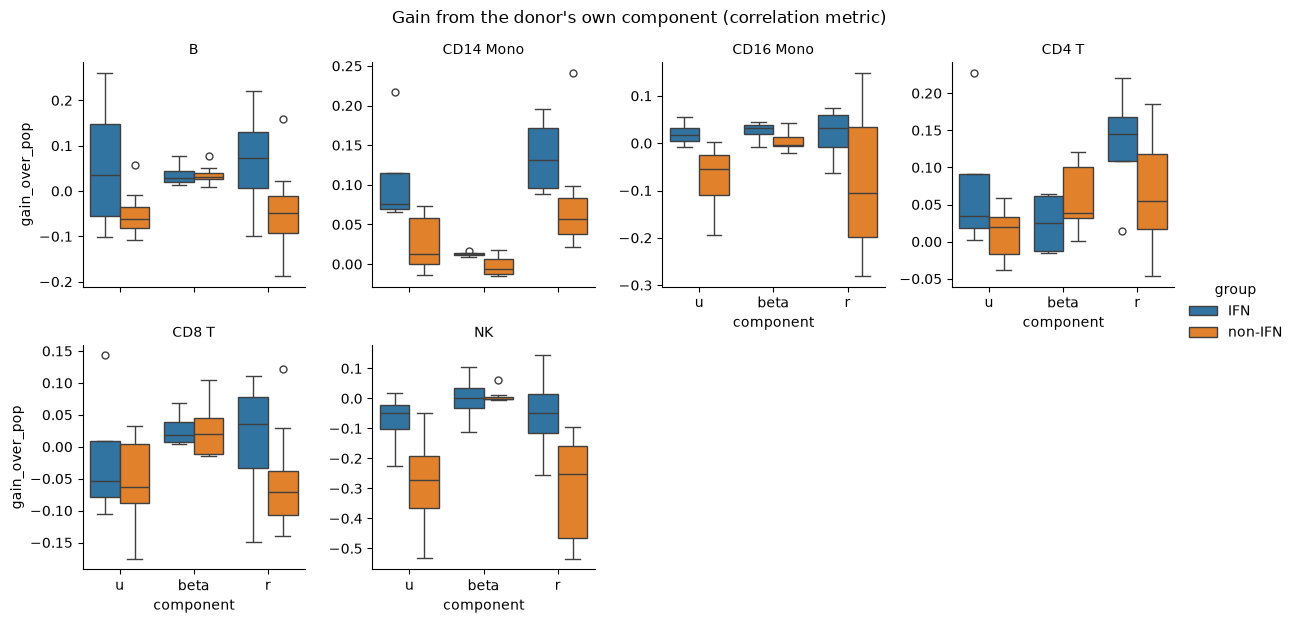

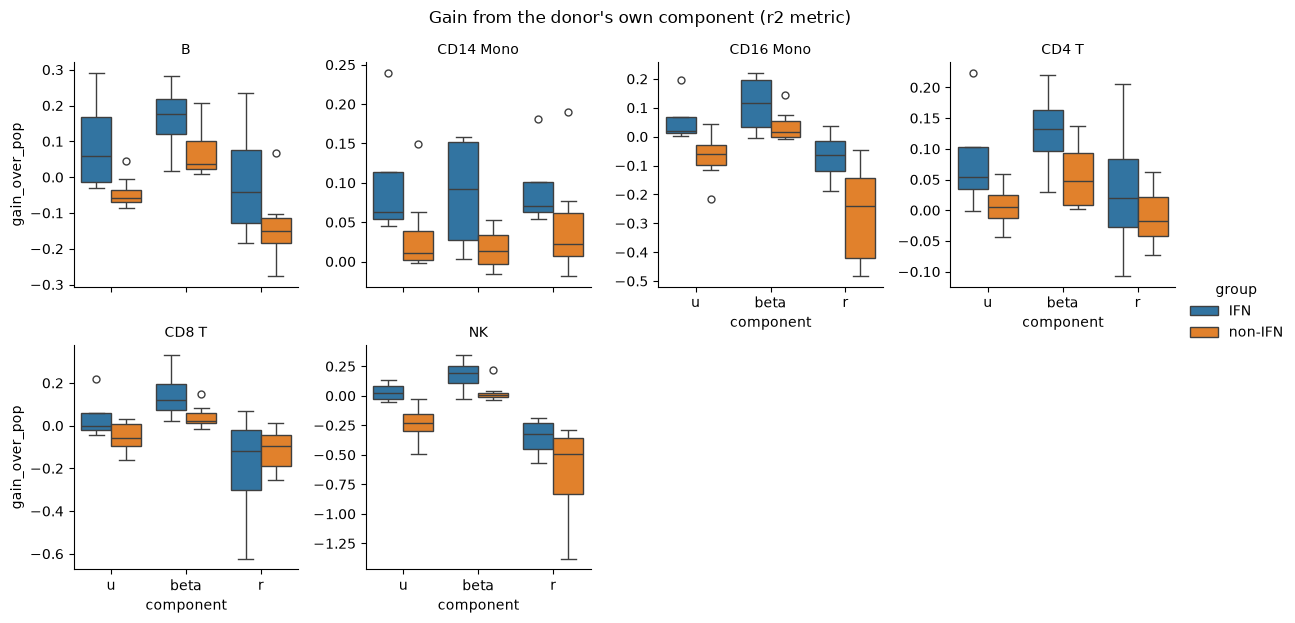

Saved to results/aim1


In [19]:
LODO.to_csv(f"{RESULTS_DIR}/lodo_per_donor.csv", index=False)
LODO_SUMMARY = LODO.groupby("cell_type")[[
    "pop_gap", "own_u_gap", "own_beta_gap", "own_r_gap",
    "ceiling_r2", "pop_r2gap", "own_u_r2gap", "own_beta_r2gap", "own_r_r2gap",
    "u_cos", "beta_rho"]].mean().round(3)
LODO_SUMMARY.to_csv(f"{RESULTS_DIR}/lodo_summary.csv")

def component_gain(suffix):
    cols = [f"own_{c}{suffix}" for c in ["u", "beta", "r"]]
    long = LODO.melt(id_vars=["cell_type", "test", "group"], value_vars=cols,
                     var_name="component", value_name="gap")
    long["component"] = long.component.str.replace("own_", "").str.replace(suffix, "")
    base = LODO.set_index(["cell_type", "test"])[f"pop{suffix}"]
    long["gain_over_pop"] = long.gap - base.loc[list(zip(long.cell_type, long.test))].to_numpy()
    return long

for suffix, label in [("_gap", "correlation"), ("_r2gap", "r2")]:
    long = component_gain(suffix)
    long.to_csv(f"{RESULTS_DIR}/lodo_component_gain_{label}.csv", index=False)
    g = sns.catplot(data=long, x="component", y="gain_over_pop", hue="group", col="cell_type",
                    col_wrap=4, kind="box", height=3, sharey=False)
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Gain from the donor's own component ({label} metric)", y=1.03)
    g.savefig(f"{RESULTS_DIR}/lodo_component_gain_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()
print(f"Saved to {RESULTS_DIR}")

**How to read:** for each cell type, look at `gain_over_pop` per component.
- **Positive:** the donor truly differs in that component (the difference is larger than the noise).
- **Near zero or negative:** no real difference there; the donor's own components come from half the data and are noisier than the population average.
- If a cell type has fewer than about 10 responsive cytokines, do not trust its results.
- Compare the two plots: if a component (typically beta) helps under **R2** but not under **correlation**, the donor differs in the **size** of its responses rather than their shape.

## 6b. Control 1: is the gain specific to the donor, or just noise?

The donor's own components are estimated from half of its cells. beta is one number per cytokine and is estimated precisely; u and r are 2,000-gene vectors and are much noisier. So a component can look "helpful" or "harmful" partly because of how noisy its estimate is, not because donors really differ in it.

**Control:** replace the component with that of **another training donor**, estimated from half A in exactly the same way (same noise level, but not this donor's biology), averaged over all other donors.

- `specific gain = own - other`
- **Positive:** the held-out donor's own component carries information about *that* donor, beyond noise. This is the evidence that individuals differ in that component.
- **Near zero:** the apparent gain (or loss) from the own component is a noise effect.

metric    correlation                   r2              
component        beta      r      u   beta      r      u
cell_type                                               
B               0.063  0.223  0.194  0.183  0.301  0.189
CD14 Mono       0.027  0.239  0.177  0.087  0.230  0.175
CD16 Mono       0.034  0.207  0.130  0.121  0.330  0.129
CD4 T           0.095  0.209  0.200  0.176  0.174  0.221
CD8 T           0.057  0.197  0.207  0.155  0.224  0.211
NK              0.025  0.259  0.219  0.154  0.397  0.187

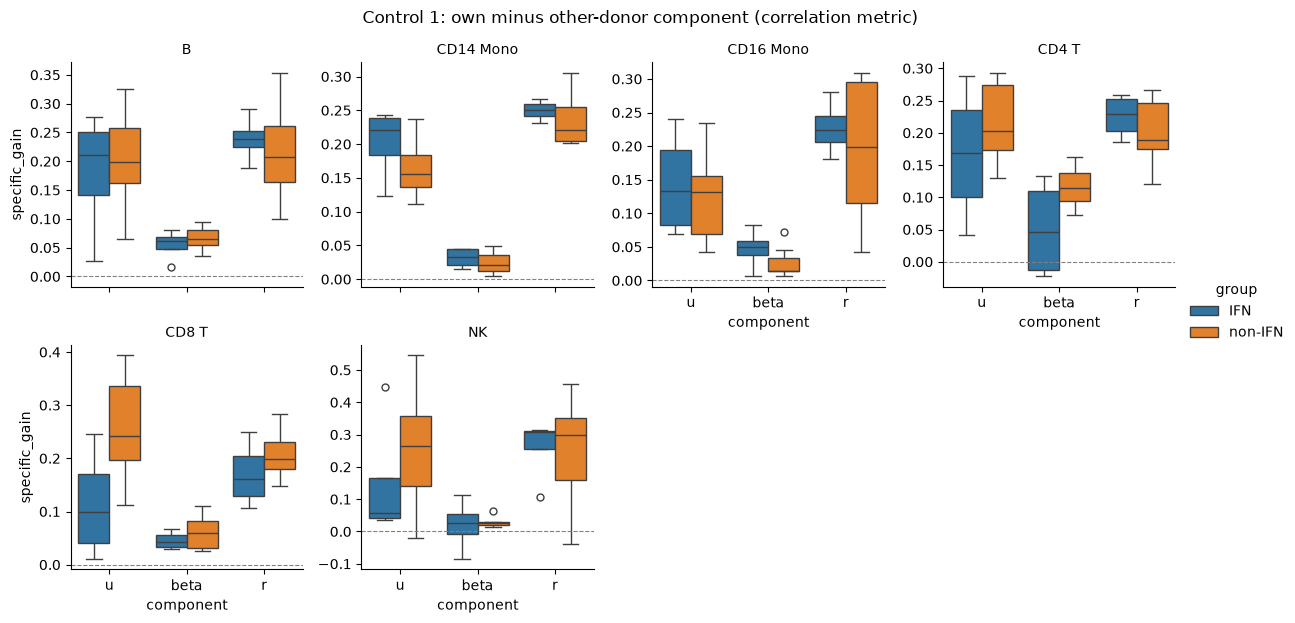

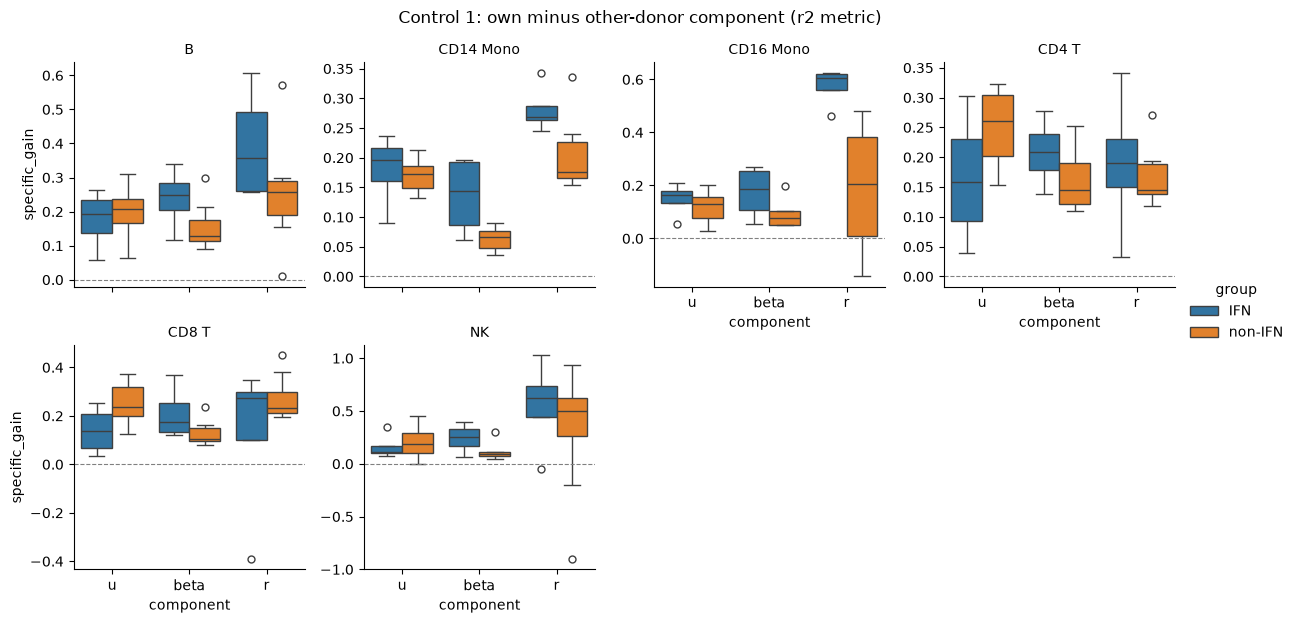

In [20]:
SPEC = []
for suffix, label in [("_gap", "correlation"), ("_r2gap", "r2")]:
    for comp_ in ["u", "beta", "r"]:
        tmp = LODO[["cell_type", "test", "group"]].copy()
        tmp["metric"], tmp["component"] = label, comp_
        tmp["own"] = LODO[f"own_{comp_}{suffix}"]
        tmp["other"] = LODO[f"other_{comp_}{suffix}"]
        tmp["specific_gain"] = tmp.own - tmp.other
        SPEC.append(tmp)
SPEC = pd.concat(SPEC, ignore_index=True)
SPEC.to_csv(f"{RESULTS_DIR}/control1_specific_gain.csv", index=False)

SPEC_SUMMARY = SPEC.pivot_table(index="cell_type", columns=["metric", "component"],
                                values="specific_gain", aggfunc="mean").round(3)
SPEC_SUMMARY.to_csv(f"{RESULTS_DIR}/control1_specific_gain_summary.csv")
display(SPEC_SUMMARY)

for label in ["correlation", "r2"]:
    g = sns.catplot(data=SPEC[SPEC.metric == label], x="component", y="specific_gain", hue="group",
                    col="cell_type", col_wrap=4, kind="box", height=3, sharey=False)
    for ax in g.axes.flat: ax.axhline(0, color="grey", lw=0.8, ls="--")
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Control 1: own minus other-donor component ({label} metric)", y=1.03)
    g.savefig(f"{RESULTS_DIR}/control1_specific_gain_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6c. Control 2: well-to-well noise (PBS wells)

Each cytokine has **one well per donor**, so half A and half B of a response come from the **same well**. The split-half ceiling therefore captures cell-sampling noise but **not** noise between wells. Differences between donors could partly be well-to-well technical noise.

Each donor has **six PBS wells** (H7-H12) with no biological difference between them. For every donor and cell type, PBS cells are split into random halves within each well, and we compare:
- **within-well distance:** half A vs half B of the **same** well
- **between-well distance:** half A of one well vs half B of a **different** well

Both use the same number of cells, so the only difference is the well.

- `ratio` = between / within. **~1:** well-to-well noise is negligible and the split-half ceiling is valid. **>1:** wells add noise.
- `well_noise_frac` = (between - within) / between: share of the between-well difference that is due to the well itself.

PBS pseudobulks per well are cached in CACHE_DIR (one pass over the PBS cells only).

In [22]:
from datetime import datetime
from zoneinfo import ZoneInfo
now = datetime.now(ZoneInfo("America/New_York"))  
print("start:", now.strftime("%H:%M:%S"))
F_WELL = os.path.join(CACHE_DIR, "pbs_wells.npz")
F_WELL_META = os.path.join(CACHE_DIR, "pbs_wells_meta.pkl")
WELL_COL = "bc1_well"

if os.path.exists(F_WELL) and os.path.exists(F_WELL_META):
    wsums = np.load(F_WELL)["sums"]; wmeta = pd.read_pickle(F_WELL_META)
    print(f"Loaded cached PBS-well pseudobulks: {wsums.shape}")
else:
    well = adata.obs[WELL_COL].astype(str).to_numpy()
    ct_arr = obs[CELLTYPE_COL].astype(str).to_numpy()
    mask = (obs[CYTO_COL].astype(str).to_numpy() == CONTROL) & np.isin(ct_arr, list(DECOMP))
    rows_pbs = np.where(mask)[0]
    whalf = np.random.default_rng(1).integers(0, 2, size=len(rows_pbs))
    keys = pd.MultiIndex.from_arrays([obs[DONOR_COL].astype(str).to_numpy()[rows_pbs],
                                      ct_arr[rows_pbs], well[rows_pbs], whalf])
    wkey, wuniq = pd.factorize(keys)
    group_of_row = np.full(adata.n_obs, -1); group_of_row[rows_pbs] = wkey
    wsums = np.zeros((len(wuniq), adata.n_vars), dtype=np.float32)

    # Same chunked scan as section 2 (large sequential reads are much faster than many small ones)
    for start in range(0, adata.n_obs, CHUNK):
        end = min(start + CHUNK, adata.n_obs)
        g = group_of_row[start:end]; m = g >= 0
        if m.any():
            X = adata.X[start:end]
            X = sp.csr_matrix(X) if not sp.issparse(X) else X.tocsr()
            rws = np.where(m)[0]
            G = sp.csr_matrix((np.ones(len(rws), np.float32), (g[m], rws)),
                              shape=(len(wuniq), end - start))
            P = G @ X
            wsums += (P.toarray() if sp.issparse(P) else np.asarray(P)).astype(np.float32)
        print(f"\r{end:,}/{adata.n_obs:,} cells", end="")

    wmeta = pd.DataFrame(list(wuniq), columns=["donor", "cell_type", "well", "half"])
    wmeta["n_cells"] = np.bincount(wkey, minlength=len(wuniq))
    np.savez(F_WELL, sums=wsums); wmeta.to_pickle(F_WELL_META)
    print(f"\nComputed and cached PBS-well pseudobulks: {wsums.shape}")

now = datetime.now(ZoneInfo("America/New_York"))  
print("start:", now.strftime("%H:%M:%S"))

start: 02:45:05
9,697,974/9,697,974 cells
Computed and cached PBS-well pseudobulks: (864, 40352)
start: 02:55:27


In [23]:
WELLNOISE = []
for ct, D in DECOMP.items():
    gidx = D["gidx"]
    for d in D["donors"]:
        sub = wmeta[(wmeta.cell_type == ct) & (wmeta.donor == d)]
        prof = {}
        for (w, h), r_ in sub.groupby(["well", "half"]):
            if r_.n_cells.sum() >= MIN_CELLS_HALF:
                prof[(w, h)] = logcpm(wsums[r_.index.to_numpy()].sum(0))[gidx]
        wells = sorted({w for (w, h) in prof if (w, 0) in prof and (w, 1) in prof})
        if len(wells) < 3: continue
        # same well, different halves
        within = np.mean([np.sum((prof[(w, 0)] - prof[(w, 1)]) ** 2) for w in wells])
        # different wells, different halves (same number of cells)
        between = np.mean([np.sum((prof[(w, 0)] - prof[(v, 1)]) ** 2)
                           for w in wells for v in wells if v != w])
        WELLNOISE.append(dict(cell_type=ct, donor=d, n_wells=len(wells),
                              within=within, between=between, ratio=between / within,
                              well_noise_frac=(between - within) / between))
WELLNOISE = pd.DataFrame(WELLNOISE)
WELLNOISE.to_csv(f"{RESULTS_DIR}/control2_well_noise_per_donor.csv", index=False)
WN_SUMMARY = WELLNOISE.groupby("cell_type")[["n_wells", "ratio", "well_noise_frac"]].median().round(3)
WN_SUMMARY.to_csv(f"{RESULTS_DIR}/control2_well_noise_summary.csv")
WN_SUMMARY

,n_wells,ratio,well_noise_frac
cell_type,,,
B,6.0,1.462,0.316
CD14 Mono,6.0,3.538,0.714
CD16 Mono,6.0,1.299,0.230
CD4 T,6.0,3.864,0.738
CD8 T,6.0,1.805,0.445
NK,6.0,1.181,0.153


In [24]:
# Upper bound on the spurious "own-component" gain caused by shared well noise.
# Well-noise energy per well = (between - within) / 2  (two wells differ by two well-noise terms).
# A component that absorbs ALL of it (r, ~2000 dims) can gain at most well_energy / truth_energy in R2.
TE = []
for ct, D in DECOMP.items():
    tb = TABLES[ct][0]; ri = [D["cytos"].index(c) for c in D["resp"]]
    for d in D["donors"]:
        T = Zmat(tb["B"], d, D["cytos"], D["gidx"])[ri]
        TE.append(dict(cell_type=ct, test=d, truth_energy=(T ** 2).sum(1).mean()))
TE = pd.DataFrame(TE)

W = WELLNOISE.rename(columns={"donor": "test"})[["cell_type", "test", "within", "between"]]
W["well_energy"] = (W.between - W.within).clip(lower=0) / 2

M = (W.merge(TE, on=["cell_type", "test"])
      .merge(LODO[["cell_type", "test", "ceiling_r2", "floor_r2"]], on=["cell_type", "test"]))
M["spurious_max"] = (M.well_energy / M.truth_energy) / (M.ceiling_r2 - M.floor_r2)

G = SPEC[SPEC.metric == "r2"].pivot_table(index=["cell_type", "test"], columns="component",
                                          values="specific_gain").reset_index()
M = M.merge(G, on=["cell_type", "test"])

CTRL2 = M.groupby("cell_type")[["spurious_max", "beta", "u", "r"]].median().round(3)
CTRL2["r_beyond_well_noise"] = (CTRL2.r - CTRL2.spurious_max).round(3)
CTRL2["u_beyond_well_noise"] = (CTRL2.u - CTRL2.spurious_max).round(3)
CTRL2.to_csv(f"{RESULTS_DIR}/control2_spurious_bound.csv")
CTRL2

,spurious_max,beta,u,r,r_beyond_well_noise,u_beyond_well_noise
cell_type,,,,,,
B,0.094,0.149,0.207,0.272,0.178,0.113
CD14 Mono,0.046,0.074,0.177,0.231,0.185,0.131
CD16 Mono,0.057,0.100,0.156,0.462,0.405,0.099
CD4 T,0.083,0.170,0.231,0.168,0.085,0.148
CD8 T,0.083,0.129,0.226,0.254,0.171,0.143
NK,0.065,0.101,0.131,0.584,0.519,0.066


## 7. Interferon group vs the rest
Train on one group and test on the other. If transfer across groups is much worse than within a group, the baseline interferon state changes the response structure.

In [27]:
X_GROUP = []
for ct, D in DECOMP.items():
    ifn = [d for d in D["donors"] if d in IFN_GROUP]
    non = [d for d in D["donors"] if d not in IFN_GROUP]
    if len(ifn) < 2 or len(non) < 2:
        print(f"{ct}: IFN_GROUP names not found, check config"); continue
    for test in D["donors"]:
        same = [d for d in (ifn if test in ifn else non) if d != test]
        other = non if test in ifn else ifn
        k = min(len(same), len(other))                     # equal training size
        for label, pool in [("within", same), ("across", other)]:
            train = list(rng.choice(pool, k, replace=False))
            r = evaluate(ct, train, test)
            if r: X_GROUP.append({**r, "setting": label})
X_GROUP = pd.DataFrame(X_GROUP)
if len(X_GROUP):
    display(X_GROUP.groupby(["cell_type", "setting"])[["pop_gap", "u_cos", "beta_rho"]].mean().round(3))

pop_gap  u_cos  beta_rho
cell_type setting                          
B         across     0.408  0.313     0.258
          within     0.635  0.552     0.727
CD14 Mono across     0.563  0.508     0.737
          within     0.693  0.581     0.720
CD16 Mono across     0.535  0.369     0.634
          within     0.650  0.388     0.645
CD4 T     across     0.453  0.334     0.429
          within     0.659  0.562     0.700
CD8 T     across     0.441  0.360     0.311
          within     0.677  0.552     0.740
NK        across     0.450  0.309     0.744
          within     0.628  0.426     0.798

In [26]:
N_REPS = 10
X_GROUP = []
for ct, D in DECOMP.items():
    ifn = [d for d in D["donors"] if d in IFN_GROUP]
    non = [d for d in D["donors"] if d not in IFN_GROUP]
    if len(ifn) < 2 or len(non) < 2:
        print(f"{ct}: not enough donors in one group"); continue
    for test in D["donors"]:
        same = [d for d in (ifn if test in ifn else non) if d != test]
        other = non if test in ifn else ifn
        k = min(len(same), len(other))                     # equal training size
        for rep in range(N_REPS):
            for label, pool in [("within", same), ("across", other)]:
                train = list(rng.choice(pool, k, replace=False))
                r = evaluate(ct, train, test, n_perm=20)
                if r: X_GROUP.append({**r, "setting": label, "rep": rep,
                                      "group": "IFN" if test in ifn else "non-IFN"})
X_GROUP = pd.DataFrame(X_GROUP)
X_GROUP.to_csv(f"{RESULTS_DIR}/ifn_group_transfer.csv", index=False)

XG_SUMMARY = X_GROUP.groupby(["cell_type", "setting"])[["pop_gap", "pop_r2gap", "u_cos", "beta_rho"]].mean().round(3)
XG_SUMMARY.to_csv(f"{RESULTS_DIR}/ifn_group_transfer_summary.csv")

# Drop from within to across, per test donor (averaged over repeats); positive = worse across groups
drop = (X_GROUP.groupby(["cell_type", "test", "group", "setting"])[["pop_gap", "beta_rho"]].mean()
        .unstack("setting"))
DROP = pd.DataFrame({"pop_gap_drop": drop[("pop_gap", "within")] - drop[("pop_gap", "across")],
                     "beta_rho_drop": drop[("beta_rho", "within")] - drop[("beta_rho", "across")]}).reset_index()
DROP.to_csv(f"{RESULTS_DIR}/ifn_group_transfer_drop.csv", index=False)
display(XG_SUMMARY)
DROP.groupby(["cell_type", "group"])[["pop_gap_drop", "beta_rho_drop"]].mean().round(3)

pop_gap  pop_r2gap  u_cos  beta_rho
cell_type setting                                     
B         across     0.420      0.391  0.310     0.267
          within     0.626      0.636  0.550     0.703
CD14 Mono across     0.563      0.585  0.496     0.737
          within     0.682      0.730  0.591     0.719
CD16 Mono across     0.533      0.523  0.374     0.637
          within     0.650      0.670  0.388     0.651
CD4 T     across     0.438      0.470  0.341     0.437
          within     0.666      0.718  0.567     0.705
CD8 T     across     0.453      0.461  0.360     0.316
          within     0.675      0.713  0.554     0.726
NK        across     0.456      0.476  0.307     0.749
          within     0.630      0.663  0.418     0.812

pop_gap_drop  beta_rho_drop
cell_type group                               
B         IFN             0.074          0.059
          non-IFN         0.272          0.625
CD14 Mono IFN            -0.029         -0.061
          non-IFN         0.193          0.005
CD16 Mono IFN            -0.070         -0.099
          non-IFN         0.224          0.079
CD4 T     IFN             0.021          0.053
          non-IFN         0.332          0.375
CD8 T     IFN             0.028          0.046
          non-IFN         0.319          0.591
NK        IFN             0.060          0.021
          non-IFN         0.230          0.084

In [27]:
ABS = (X_GROUP.groupby(["cell_type", "group", "setting"])[["pop_gap", "beta_rho"]].mean()
       .unstack("setting").round(3))
ABS.to_csv(f"{RESULTS_DIR}/ifn_group_transfer_absolute.csv")
ABS

pop_gap        beta_rho       
setting            across within   across within
cell_type group                                 
B         IFN       0.422  0.496    0.455  0.514
          non-IFN   0.419  0.691    0.173  0.798
CD14 Mono IFN       0.581  0.552    0.626  0.564
          non-IFN   0.555  0.748    0.792  0.797
CD16 Mono IFN       0.577  0.507    0.414  0.316
          non-IFN   0.508  0.732    0.764  0.843
CD4 T     IFN       0.486  0.507    0.323  0.375
          non-IFN   0.414  0.746    0.495  0.869
CD8 T     IFN       0.508  0.535    0.433  0.479
          non-IFN   0.426  0.745    0.258  0.849
NK        IFN       0.485  0.545    0.648  0.669
          non-IFN   0.442  0.672    0.800  0.884

## 8. Cytokine-family holdout
For each donor: build the axis **without** one family, then ask what fraction of that family's response the axis still explains.
Compared with the full axis (all cytokines) and a random axis (floor).

Check the cytokine names in your file and complete the `FAMILIES` rules below.

In [29]:
def norm_name(s): return str(s).upper().replace("-", "").replace("_", "").replace(" ", "")

FAMILIES = {
    "interferon": lambda n: n.startswith("IFN"),
    "common_gamma_chain": lambda n: n in {"IL2", "IL4", "IL7", "IL9", "IL15", "IL21"},
    "IL1": lambda n: n in {"IL1ALPHA", "IL1BETA", "IL1RA", "IL33", "IL36ALPHA", "IL36RA"},
}

def explained(Z, u):
    return ((Z @ u) ** 2).sum() / (Z ** 2).sum()

FAM = []
for ct, D in DECOMP.items():
    names = {c: norm_name(c) for c in D["cytos"]}
    for fam, rule in FAMILIES.items():
        inF = [c for c in D["resp"] if rule(names[c])]
        if len(inF) < 2: continue
        for d in D["donors"]:
            Z = D["comp"][d]["Z"]; ci = {c: i for i, c in enumerate(D["cytos"])}
            ZF = Z[[ci[c] for c in inF]]
            Zrest = Z[[ci[c] for c in D["cytos"] if c not in inF]]
            rand = normalize(rng.normal(size=Z.shape[1]))
            FAM.append(dict(cell_type=ct, family=fam, donor=d, n=len(inF),
                            with_family=explained(ZF, D["comp"][d]["u"]),
                            without_family=explained(ZF, shared_axis(Zrest)),
                            random_axis=explained(ZF, rand)))
FAM = pd.DataFrame(FAM)
print("cytokine names in data (check FAMILIES rules):",
      sorted({norm_name(c) for D in DECOMP.values() for c in D["cytos"]})[:40], "...")
if len(FAM):
    display(FAM.groupby(["cell_type", "family"])[["with_family", "without_family", "random_axis"]].mean().round(3))

cytokine names in data (check FAMILIES rules): ['41BBL', 'ADSF', 'APRIL', 'BAFF', 'C5A', 'CD27L', 'CD30L', 'CD40L', 'CT1', 'FASL', 'FLT3L', 'GCSF', 'GITRL', 'GMCSF', 'IFNALPHA1', 'IFNBETA', 'IFNEPSILON', 'IFNGAMMA', 'IFNLAMBDA1', 'IFNLAMBDA2', 'IFNLAMBDA3', 'IFNOMEGA', 'IL10', 'IL11', 'IL12', 'IL13', 'IL15', 'IL16', 'IL17A', 'IL17B', 'IL17C', 'IL17D', 'IL17E', 'IL17F', 'IL18RA', 'IL19', 'IL1ALPHA', 'IL1BETA', 'IL1RA', 'IL2'] ...


with_family  without_family  random_axis
cell_type family                                                      
B         IL1                       0.509           0.469        0.000
          common_gamma_chain        0.460           0.390        0.000
          interferon                0.487           0.385        0.000
CD14 Mono IL1                       0.523           0.474        0.001
          common_gamma_chain        0.435           0.367        0.000
          interferon                0.493           0.279        0.001
CD16 Mono common_gamma_chain        0.354           0.276        0.001
          interferon                0.368           0.230        0.000
CD4 T     IL1                       0.575           0.538        0.000
          common_gamma_chain        0.493           0.395        0.000
          interferon                0.577           0.448        0.001
CD8 T     IL1                       0.468           0.425        0.001
          common_gamma_chain        0.426           0.302        0.000
          interferon                0.516           0.397        0.001
NK        common_gamma_chain        0.414           0.292        0.001
          interferon                0.432           0.315        0.000

**How to read:** if `without_family` stays close to `with_family`, the shared axis is general. If it drops toward `random_axis`, the axis was mostly that family's response.

## 9. How many donors are needed?
Train on k donors (random subsets, several repeats) and test on the held-out donor.

In [30]:
CURVE = []
for ct, D in DECOMP.items():
    for test in D["donors"]:
        others = [d for d in D["donors"] if d != test]
        for k in [2, 4, 6, 8, len(others)]:
            for rep in range(3 if k < len(others) else 1):
                train = list(rng.choice(others, k, replace=False))
                r = evaluate(ct, train, test, n_perm=10)
                if r: CURVE.append({**r, "k": k})
CURVE = pd.DataFrame(CURVE)

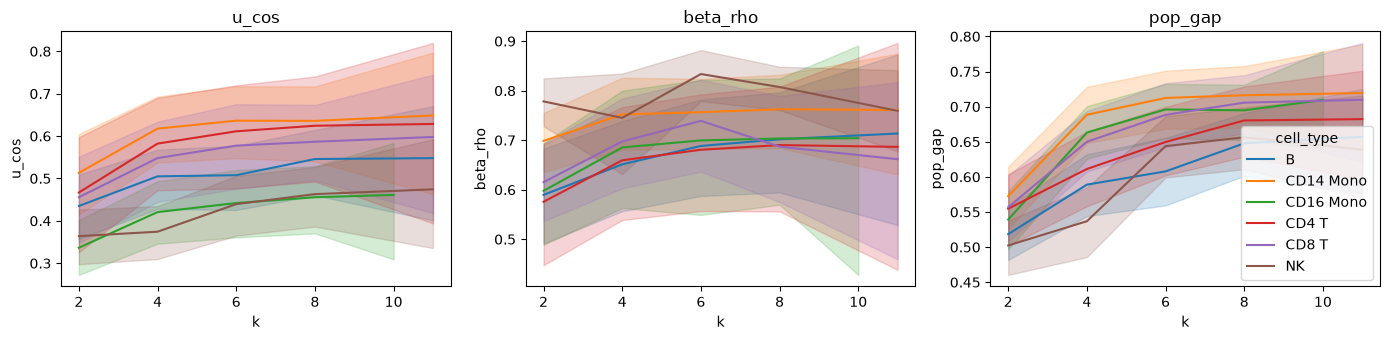

Saved to results/aim1


In [33]:
CURVE.to_csv(f"{RESULTS_DIR}/donor_curve.csv", index=False)
CURVE.groupby(["cell_type", "k"])[["u_cos", "beta_rho", "pop_gap", "pop_r2gap"]].mean().round(3) \
     .to_csv(f"{RESULTS_DIR}/donor_curve_summary.csv")
FAM.to_csv(f"{RESULTS_DIR}/family_holdout.csv", index=False)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for a, col in zip(ax, ["u_cos", "beta_rho", "pop_gap"]):
    sns.lineplot(data=CURVE, x="k", y=col, hue="cell_type", ax=a, legend=a is ax[-1])
    a.set_title(col)
plt.tight_layout()
fig.savefig(f"{RESULTS_DIR}/donor_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS_DIR}")

## 10. Robustness: are the findings specific to COMPASS?

The two core findings are re-tested with decompositions other than COMPASS:
- **compass**: one axis = normalized mean response (original)
- **svd1**: one axis = top singular vector of the response matrix
- **svd3**: a 3-dimensional shared subspace (top 3 singular vectors)

For every method, population components come from the training donors, the held-out donor's own components from half A of its cells (axes rotated to match the population axes), and everything is scored against half B with the R2 floor/ceiling scale.

**Test 1** (donor-specific signal): `specific_x = own_x - other_x` for each component. Positive in all methods means individuals differ in that component regardless of the decomposition.
**Test 2** (interferon groups): transfer within vs across groups. If non-IFN donors transfer well among themselves and IFN donors do not, for every method, the finding does not depend on COMPASS.

In [37]:
import os
RESULTS_DIR = "results/aim1"
os.makedirs(RESULTS_DIR, exist_ok=True)

def r2(P, T):
    return 1 - ((P - T) ** 2).sum() / ((T ** 2).sum() + 1e-12)

print("Ready:", list(DECOMP))

Ready: ['B', 'CD14 Mono', 'CD16 Mono', 'CD4 T', 'CD8 T', 'NK']


In [21]:
# ===== Robustness: are the findings specific to COMPASS? =====
# Three decompositions of the same response matrix Z (cytokines x genes):
#   compass : 1 axis  = normalized mean response            (the original)
#   svd1    : 1 axis  = top right-singular vector of Z      (a different shared axis)
#   svd3    : 3 axes  = top 3 right-singular vectors of Z   (a low-dimensional shared subspace)
# In every case: coefficients = projection of Z on the axes, residual = the rest.
METHODS = {"compass": 1, "svd1": 1, "svd3": 3}

def basis(Z, method):
    if method == "compass":
        return normalize(Z.mean(0))[None, :]
    k = METHODS[method]
    _, _, Vt = np.linalg.svd(Z, full_matrices=False)
    U = Vt[:k].copy()
    sgn = np.sign(U @ Z.mean(0)); sgn[sgn == 0] = 1       # orient each axis with the mean response
    return U * sgn[:, None]

def align(U, U_ref):
    # rotate U (k x G) to best match U_ref (orthogonal Procrustes); for k = 1 this only fixes the sign
    P, _, Qt = np.linalg.svd(U_ref @ U.T)
    return (P @ Qt) @ U

def split(Z, U):
    B = Z @ U.T                     # coefficients (n x k)
    return B, Z - B @ U             # residual (n x G)

def evaluate_generic(ct, train, test, method, controls=True, n_perm=20):
    tb, ex = TABLES[ct]
    cytos = common_cytokines(tb["full"], train + [test])
    gidx = select_genes(tb["full"], train, ex, cytos)
    resp = responsive(tb, train, cytos, gidx)
    if len(cytos) < MIN_CYTOKINES or len(resp) < 3: return None
    ri = [cytos.index(c) for c in resp]

    # population components from the training donors (pooled axes, donor-averaged coefficients/residuals)
    Ztr = {d: Zmat(tb["full"], d, cytos, gidx) for d in train}
    U_p = basis(np.vstack(list(Ztr.values())), method)
    parts = [split(Ztr[d], U_p) for d in train]
    B_p = np.mean([p[0] for p in parts], 0); R_p = np.mean([p[1] for p in parts], 0)

    truth = Zmat(tb["B"], test, cytos, gidx)[ri]
    halfA_full = Zmat(tb["A"], test, cytos, gidx)

    def swaps(ZA):
        # a donor's own components, estimated from half A of its cells
        U_o = align(basis(ZA, method), U_p)
        B_on_pop, _ = split(ZA, U_p)
        _, R_o = split(ZA, U_o)
        return {"u": B_p @ U_o + R_p, "beta": B_on_pop @ U_p + R_p, "r": B_p @ U_p + R_o}

    res = {"pop": r2((B_p @ U_p + R_p)[ri], truth)}
    for k, v in swaps(halfA_full).items():
        res["own_" + k] = r2(v[ri], truth)
    if controls:
        acc = {}
        for o in train:
            for k, v in swaps(Zmat(tb["A"], o, cytos, gidx)).items():
                acc.setdefault(k, []).append(r2(v[ri], truth))
        for k, v in acc.items():
            res["other_" + k] = np.mean(v)

    halfA = halfA_full[ri]
    ceil = 1 - ((halfA - truth) ** 2).sum() / 2 / ((truth ** 2).sum() + 1e-12)
    P = (B_p @ U_p + R_p)[ri]
    floor = np.mean([r2(P[rng.permutation(len(ri))], truth) for _ in range(n_perm)])
    scale = lambda x: (x - floor) / (ceil - floor + 1e-12)
    out = dict(cell_type=ct, test=test, method=method, pop_gap=scale(res["pop"]))
    for k in ["u", "beta", "r"]:
        out[f"own_{k}_gap"] = scale(res["own_" + k])
        if controls:
            out[f"specific_{k}"] = scale(res["own_" + k]) - scale(res["other_" + k])
    return out

In [22]:
# Test 1: leave-one-donor-out with the noise-matched "other donor" control, for each decomposition
ROB = []
for method in METHODS:
    for ct, D in DECOMP.items():
        for test in D["donors"]:
            r = evaluate_generic(ct, [d for d in D["donors"] if d != test], test, method)
            if r: ROB.append(r)
    print(f"{method}: done")
ROB = pd.DataFrame(ROB)
ROB.to_csv(f"{RESULTS_DIR}/robustness_lodo.csv", index=False)
ROB_SUMMARY = ROB.groupby(["method", "cell_type"])[
    ["pop_gap", "specific_u", "specific_beta", "specific_r"]].mean().round(3)
ROB_SUMMARY.to_csv(f"{RESULTS_DIR}/robustness_lodo_summary.csv")
ROB_SUMMARY

compass: done
svd1: done
svd3: done


pop_gap  specific_u  specific_beta  specific_r
method  cell_type                                                
compass B            0.647       0.123          0.281       0.330
        CD14 Mono    0.740       0.151          0.141       0.241
        CD16 Mono    0.702       0.081          0.176       0.366
        CD4 T        0.729       0.114          0.270       0.187
        CD8 T        0.704       0.161          0.239       0.238
        NK           0.646       0.173          0.294       0.455
svd1    B            0.643       0.158          0.358       0.226
        CD14 Mono    0.743       0.078          0.162       0.218
        CD16 Mono    0.705       0.100          0.217       0.237
        CD4 T        0.726       0.148          0.319       0.156
        CD8 T        0.711       0.185          0.293       0.177
        NK           0.646       0.240          0.384       0.305
svd3    B            0.643       0.067          0.494       0.081
        CD14 Mono    0.744       0.098          0.264       0.082
        CD16 Mono    0.702       0.122          0.313       0.132
        CD4 T        0.727       0.047          0.396       0.038
        CD8 T        0.700       0.107          0.367       0.060
        NK           0.651       0.173          0.462       0.165

In [23]:
# Test 2: interferon-group transfer (within vs across group), for each decomposition
N_REPS = 10
ROB_IFN = []
for method in METHODS:
    for ct, D in DECOMP.items():
        ifn = [d for d in D["donors"] if d in IFN_GROUP]
        non = [d for d in D["donors"] if d not in IFN_GROUP]
        if len(ifn) < 2 or len(non) < 2: continue
        for test in D["donors"]:
            same = [d for d in (ifn if test in ifn else non) if d != test]
            other = non if test in ifn else ifn
            k = min(len(same), len(other))
            for rep in range(N_REPS):
                for label, pool in [("within", same), ("across", other)]:
                    train = list(rng.choice(pool, k, replace=False))
                    r = evaluate_generic(ct, train, test, method, controls=False, n_perm=10)
                    if r: ROB_IFN.append({**r, "setting": label,
                                          "group": "IFN" if test in ifn else "non-IFN"})
    print(f"{method}: done")
ROB_IFN = pd.DataFrame(ROB_IFN)
ROB_IFN.to_csv(f"{RESULTS_DIR}/robustness_ifn.csv", index=False)
ROB_IFN_SUMMARY = (ROB_IFN.groupby(["method", "cell_type", "group", "setting"])["pop_gap"].mean()
                   .unstack("setting").round(3))
ROB_IFN_SUMMARY.to_csv(f"{RESULTS_DIR}/robustness_ifn_summary.csv")
ROB_IFN_SUMMARY

compass: done
svd1: done
svd3: done


setting                    across  within
method  cell_type group                  
compass B         IFN       0.407   0.563
                  non-IFN   0.449   0.709
        CD14 Mono IFN       0.615   0.693
                  non-IFN   0.611   0.780
        CD16 Mono IFN       0.564   0.627
                  non-IFN   0.546   0.741
        CD4 T     IFN       0.484   0.648
                  non-IFN   0.535   0.802
        CD8 T     IFN       0.510   0.606
                  non-IFN   0.498   0.800
        NK        IFN       0.473   0.589
                  non-IFN   0.510   0.733
svd1    B         IFN       0.408   0.559
                  non-IFN   0.443   0.714
        CD14 Mono IFN       0.605   0.693
                  non-IFN   0.610   0.777
        CD16 Mono IFN       0.562   0.624
                  non-IFN   0.546   0.745
        CD4 T     IFN       0.489   0.651
                  non-IFN   0.536   0.798
        CD8 T     IFN       0.498   0.609
                  non-IFN   0.495   0.798
        NK        IFN       0.474   0.583
                  non-IFN   0.514   0.743
svd3    B         IFN       0.406   0.561
                  non-IFN   0.446   0.720
        CD14 Mono IFN       0.611   0.692
                  non-IFN   0.611   0.783
        CD16 Mono IFN       0.563   0.625
                  non-IFN   0.547   0.752
        CD4 T     IFN       0.491   0.650
                  non-IFN   0.539   0.798
        CD8 T     IFN       0.488   0.612
                  non-IFN   0.495   0.795
        NK        IFN       0.483   0.600
                  non-IFN   0.507   0.741

## 11. Decomposition-free check: size or direction?

The main finding (donors differ mainly in beta) is tested **without any shared axis or model**. For two response vectors of the same cytokine and cell type, the squared difference splits exactly:

$$\|a-b\|^2 = \underbrace{(|a|-|b|)^2}_{\text{magnitude}} + \underbrace{2|a||b|(1-\cos(a,b))}_{\text{direction}}$$

- **within**: half A vs half B of the same donor (sampling noise)
- **between**: half A of one donor vs half B of another (same cell numbers)
- **excess** = between - within, as a fraction of the typical response energy
- Well-to-well noise is nearly isotropic, so it lands almost entirely in the direction part; the PBS-well estimate (section 6c) is subtracted from it (`direction_after_well_noise`).

**How to read:** `share_magnitude` near 1 means donors differ mainly in how strongly they respond (consistent with the beta result), near 0 means they differ mainly in the shape of the response. The by-pair table shows whether interferon donors differ from the others in size or in shape.

In [44]:
# ===== Decomposition-free test: do donors differ in response SIZE or response DIRECTION? =====
# For two response vectors a and b (same cytokine, same cell type), the squared difference splits exactly:
#     ||a - b||^2 = (|a| - |b|)^2            +  2 |a| |b| (1 - cos(a, b))
#                   magnitude part (M)          direction part (D)
# No shared axis or model is involved.
#   within  : half A vs half B of the SAME donor   -> sampling noise only
#   between : half A of donor d vs half B of donor e -> sampling noise + donor difference + well noise
# Both use half-samples, so cell numbers match. Excess = between - within.
# Well-to-well noise is (almost) isotropic, so it falls into D, not M; it is estimated from PBS wells
# (section 6c) and subtracted from the direction excess.

# Reload PBS-well results if the kernel was restarted
if "WELLNOISE" not in globals():
    wsums = np.load(os.path.join(CACHE_DIR, "pbs_wells.npz"))["sums"]
    wmeta = pd.read_pickle(os.path.join(CACHE_DIR, "pbs_wells_meta.pkl"))
    WELLNOISE = []
    for ct, D in DECOMP.items():
        for d in D["donors"]:
            sub = wmeta[(wmeta.cell_type == ct) & (wmeta.donor == d)]
            prof = {(w, h): logcpm(wsums[r_.index.to_numpy()].sum(0))[D["gidx"]]
                    for (w, h), r_ in sub.groupby(["well", "half"]) if r_.n_cells.sum() >= MIN_CELLS_HALF}
            wells = sorted({w for (w, h) in prof if (w, 0) in prof and (w, 1) in prof})
            if len(wells) < 3: continue
            within = np.mean([np.sum((prof[(w, 0)] - prof[(w, 1)]) ** 2) for w in wells])
            between = np.mean([np.sum((prof[(w, 0)] - prof[(v, 1)]) ** 2) for w in wells for v in wells if v != w])
            WELLNOISE.append(dict(cell_type=ct, donor=d, within=within, between=between))
    WELLNOISE = pd.DataFrame(WELLNOISE)

def mag_dir(a, b):
    na, nb = np.linalg.norm(a, axis=1), np.linalg.norm(b, axis=1)
    cos = (a * b).sum(1) / (na * nb + 1e-12)
    return (na - nb) ** 2, 2 * na * nb * (1 - cos)

def pair_type(d, e):
    k = int(d in IFN_GROUP) + int(e in IFN_GROUP)
    return ["non-IFN x non-IFN", "IFN x non-IFN", "IFN x IFN"][k]

MAGDIR = []
for ct, D in DECOMP.items():
    tb = TABLES[ct][0]; ri = [D["cytos"].index(c) for c in D["resp"]]
    A = {d: Zmat(tb["A"], d, D["cytos"], D["gidx"])[ri] for d in D["donors"]}
    B = {d: Zmat(tb["B"], d, D["cytos"], D["gidx"])[ri] for d in D["donors"]}
    # typical response energy, used to put everything on a common scale
    energy = np.mean([((A[d] ** 2).sum(1) + (B[d] ** 2).sum(1)).mean() / 2 for d in D["donors"]])
    wn = WELLNOISE[WELLNOISE.cell_type == ct]
    well = (wn.between - wn.within).clip(lower=0).mean() if len(wn) else 0.0   # ~2 x well-noise energy
    within = {d: mag_dir(A[d], B[d]) for d in D["donors"]}
    for d in D["donors"]:
        for e in D["donors"]:
            if d == e: continue
            M_b, D_b = mag_dir(A[d], B[e])
            M_w = (within[d][0] + within[e][0]) / 2; D_w = (within[d][1] + within[e][1]) / 2
            MAGDIR.append(dict(cell_type=ct, pair=pair_type(d, e),
                               mag_excess=(M_b - M_w).mean() / energy,
                               dir_excess=(D_b - D_w).mean() / energy,
                               dir_excess_wellcorr=((D_b - D_w).mean() - well) / energy))
MAGDIR = pd.DataFrame(MAGDIR)

In [42]:
def summarize(df):
    s = df.mean(numeric_only=True)
    tot = max(s.mag_excess, 0) + max(s.dir_excess_wellcorr, 0)
    return pd.Series({"magnitude": s.mag_excess, "direction": s.dir_excess,
                      "direction_after_well_noise": s.dir_excess_wellcorr,
                      "share_magnitude": max(s.mag_excess, 0) / tot if tot > 0 else np.nan})

MAGDIR_SUMMARY = MAGDIR.groupby("cell_type").apply(summarize).round(3)
MAGDIR_BY_PAIR = MAGDIR.groupby(["cell_type", "pair"]).apply(summarize).round(3)
MAGDIR.to_csv(f"{RESULTS_DIR}/magnitude_direction_pairs.csv", index=False)
MAGDIR_SUMMARY.to_csv(f"{RESULTS_DIR}/magnitude_direction_summary.csv")
MAGDIR_BY_PAIR.to_csv(f"{RESULTS_DIR}/magnitude_direction_by_pair.csv")
print("All donor pairs (excess over within-donor noise, as a fraction of typical response energy):")
display(MAGDIR_SUMMARY)
print("By donor-pair type:")
MAGDIR_BY_PAIR

All donor pairs (excess over within-donor noise, as a fraction of typical response energy):


,magnitude,direction,direction_after_well_noise,share_magnitude
cell_type,,,,
B,0.168,0.434,0.253,0.399
CD14 Mono,0.129,0.481,0.360,0.264
CD16 Mono,0.172,0.280,0.182,0.486
CD4 T,0.184,0.445,0.250,0.423
CD8 T,0.146,0.335,0.192,0.433
NK,0.145,0.204,0.129,0.530


By donor-pair type:


magnitude  direction  direction_after_well_noise  \
cell_type pair                                                                  
B         IFN x IFN              0.084      0.364                       0.182   
          IFN x non-IFN          0.211      0.593                       0.411   
          non-IFN x non-IFN      0.137      0.269                       0.087   
CD14 Mono IFN x IFN              0.074      0.406                       0.284   
          IFN x non-IFN          0.156      0.557                       0.435   
          non-IFN x non-IFN      0.111      0.411                       0.289   
CD16 Mono IFN x IFN              0.045      0.290                       0.192   
          IFN x non-IFN          0.204      0.318                       0.220   
          non-IFN x non-IFN      0.164      0.227                       0.128   
CD4 T     IFN x IFN              0.115      0.442                       0.247   
          IFN x non-IFN          0.264      0.629                       0.434   
          non-IFN x non-IFN      0.107      0.237                       0.041   
CD8 T     IFN x IFN              0.215      0.201                       0.057   
          IFN x non-IFN          0.204      0.480                       0.336   
          non-IFN x non-IFN      0.066      0.198                       0.055   
NK        IFN x IFN              0.092      0.139                       0.064   
          IFN x non-IFN          0.164      0.323                       0.248   
          non-IFN x non-IFN      0.135      0.082                       0.007   

                             share_magnitude  
cell_type pair                                
B         IFN x IFN                    0.314  
          IFN x non-IFN                0.339  
          non-IFN x non-IFN            0.610  
CD14 Mono IFN x IFN                    0.206  
          IFN x non-IFN                0.264  
          non-IFN x non-IFN            0.277  
CD16 Mono IFN x IFN                    0.190  
          IFN x non-IFN                0.482  
          non-IFN x non-IFN            0.562  
CD4 T     IFN x IFN                    0.317  
          IFN x non-IFN                0.378  
          non-IFN x non-IFN            0.721  
CD8 T     IFN x IFN                    0.790  
          IFN x non-IFN                0.377  
          non-IFN x non-IFN            0.544  
NK        IFN x IFN                    0.590  
          IFN x non-IFN                0.398  
          non-IFN x non-IFN            0.952

## 12. Asymmetric vs symmetric noise estimate (Parse)

In the 1M-scBloodNL replication, an asymmetric noise estimate (half of a donor's cells compared with the nearly noise-free mean of the other donors, corrected with a half-vs-half noise term) produced strong spurious correlations. This section tests whether the same estimator also misleads on Parse.

- `rho_size_vs_cells`, `rho_shape_vs_cells`: correlation of a donor's deviation with its cell count. A correct estimator should not track a donor's noise level. **Main readout:** a strong, consistent negative `rho_size_vs_cells` for `asym` (donors with fewer cells look more different in size) that is absent for `sym` means the asymmetric estimator manufactures donor differences from noise. (On synthetic data with identical donors: asym about -0.94, sym about 0.)
- `frac_negative_shape`: share of negative shape values. With real donor differences a correct estimator gives few negatives; if donors barely differ, about half are negative by chance, so read this together with the correlations.
- `ifn_minus_other_*`: interferon-group contrast under each estimator; a change between estimators means the estimator alone can create or hide group differences.
- Residual caveat: when donors differ strongly in cell count, even the symmetric estimator keeps a small size bias.

In [45]:
# ===== Step 2a: does the asymmetric noise estimate create spurious donor differences in Parse too? =====
# Two ways to measure how far a donor's response is from the others, split into size and shape:
#   asymmetric : half A of donor d  vs  mean full response of the other donors (almost noise-free),
#                minus half of the within-donor (half A vs half B) term      <- the flawed version
#   symmetric  : half A of donor d  vs  half B of each other donor, minus the within-donor terms
# Truth cannot be negative. The flawed version is expected to (1) give negative shape values and
# (2) make deviations depend on how many cells a donor has (i.e. on its noise level).
def mag_shape_rows(a, b):
    na, nb = np.linalg.norm(a, axis=-1), np.linalg.norm(b, axis=-1)
    cos = (a * b).sum(-1) / (na * nb + 1e-12)
    return (na - nb) ** 2, 2 * na * nb * (1 - cos)

ncell = (meta.groupby(["donor", "cell_type", "cytokine"], observed=True).n_cells.sum())

ASYM = []
for ct, D in DECOMP.items():
    tb = TABLES[ct][0]; ri = [D["cytos"].index(c) for c in D["resp"]]
    A = {d: Zmat(tb["A"], d, D["cytos"], D["gidx"])[ri] for d in D["donors"]}
    B = {d: Zmat(tb["B"], d, D["cytos"], D["gidx"])[ri] for d in D["donors"]}
    Fm = {d: Zmat(tb["full"], d, D["cytos"], D["gidx"])[ri] for d in D["donors"]}
    energy = np.mean([((A[d] ** 2).sum(1) + (B[d] ** 2).sum(1)).mean() / 2 for d in D["donors"]])
    W = {d: mag_shape_rows(A[d], B[d]) for d in D["donors"]}
    for d in D["donors"]:
        others = [e for e in D["donors"] if e != d]
        # asymmetric
        m = np.mean([Fm[e] for e in others], 0)
        Mr, Sr = mag_shape_rows(A[d], m)
        asym_size, asym_shape = (Mr - W[d][0] / 2) / energy, (Sr - W[d][1] / 2) / energy
        # symmetric
        ex_M, ex_S = [], []
        for e in others:
            Mb, Sb = mag_shape_rows(A[d], B[e])
            ex_M.append(Mb - (W[d][0] + W[e][0]) / 2); ex_S.append(Sb - (W[d][1] + W[e][1]) / 2)
        sym_size, sym_shape = np.mean(ex_M, 0) / energy, np.mean(ex_S, 0) / energy
        for j, c in enumerate(D["resp"]):
            ASYM.append(dict(cell_type=ct, donor=d, cytokine=c,
                             n_cells=int(ncell.get((d, ct, c), 0)),
                             ifn=d in IFN_GROUP,
                             asym_size=asym_size[j], asym_shape=asym_shape[j],
                             sym_size=sym_size[j], sym_shape=sym_shape[j]))
ASYM = pd.DataFrame(ASYM)
ASYM.to_csv(f"{RESULTS_DIR}/asymmetric_vs_symmetric_per_donor.csv", index=False)

frac_negative_shape  rho_size_vs_cells  \
cell_type estimator                                           
B         asym                     0.125             -0.580   
          sym                      0.000             -0.147   
CD14 Mono asym                     0.000             -0.601   
          sym                      0.000             -0.245   
CD16 Mono asym                     0.227             -0.509   
          sym                      0.045             -0.200   
CD4 T     asym                     0.013             -0.056   
          sym                      0.000             -0.273   
CD8 T     asym                     0.033             -0.042   
          sym                      0.017             -0.392   
NK        asym                     0.312             -0.448   
          sym                      0.062             -0.392   

                     rho_shape_vs_cells  ifn_minus_other_shape  \
cell_type estimator                                              
B         asym                    0.147                  0.232   
          sym                    -0.350                  0.144   
CD14 Mono asym                    0.266                  0.122   
          sym                    -0.119                  0.052   
CD16 Mono asym                    0.736                  0.213   
          sym                     0.664                  0.052   
CD4 T     asym                   -0.364                  0.240   
          sym                    -0.182                  0.197   
CD8 T     asym                   -0.210                  0.124   
          sym                    -0.126                  0.094   
NK        asym                   -0.070                  0.205   
          sym                    -0.182                  0.096   

                     ifn_minus_other_size  
cell_type estimator                        
B         asym                     -0.065  
          sym                       0.012  
CD14 Mono asym                     -0.061  
          sym                       0.009  
CD16 Mono asym                     -0.206  
          sym                      -0.021  
CD4 T     asym                      0.041  
          sym                       0.063  
CD8 T     asym                      0.079  
          sym                       0.093  
NK        asym                     -0.120  
          sym                      -0.005

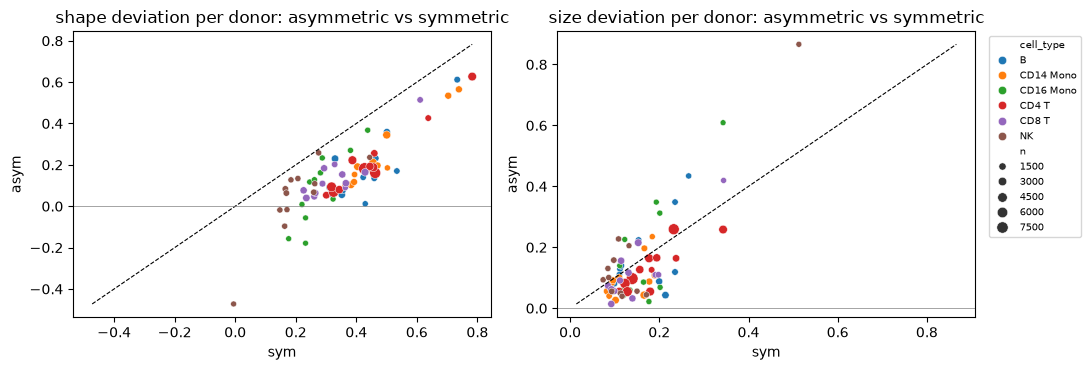

In [46]:
rows = []
for ct, g in ASYM.groupby("cell_type"):
    for est in ["asym", "sym"]:
        # donor-level averages over responsive cytokines
        dl = g.groupby("donor").agg(dev_size=(f"{est}_size", "mean"), dev_shape=(f"{est}_shape", "mean"),
                                    n_cells=("n_cells", "median"), ifn=("ifn", "first"))
        dl["ifn"] = dl["ifn"].astype(bool)
        rows.append(dict(
            cell_type=ct, estimator=est,
            frac_negative_shape=(g[f"{est}_shape"] < 0).mean(),
            # does the deviation track the donor's cell count (noise level)?
            rho_size_vs_cells=spearmanr(dl.dev_size, np.log(dl.n_cells))[0],
            rho_shape_vs_cells=spearmanr(dl.dev_shape, np.log(dl.n_cells))[0],
            # interferon-group contrast (difference in mean deviation)
            ifn_minus_other_shape=dl[dl.ifn].dev_shape.mean() - dl[~dl.ifn].dev_shape.mean(),
            ifn_minus_other_size=dl[dl.ifn].dev_size.mean() - dl[~dl.ifn].dev_size.mean()))
ASYM_SUMMARY = pd.DataFrame(rows).set_index(["cell_type", "estimator"]).round(3)
ASYM_SUMMARY.to_csv(f"{RESULTS_DIR}/asymmetric_vs_symmetric_summary.csv")
display(ASYM_SUMMARY)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, part in zip(ax, ["shape", "size"]):
    dd = ASYM.groupby(["cell_type", "donor"]).agg(asym=(f"asym_{part}", "mean"), sym=(f"sym_{part}", "mean"),
                                                  n=("n_cells", "median")).reset_index()
    sns.scatterplot(data=dd, x="sym", y="asym", hue="cell_type", size="n", ax=a, legend=a is ax[-1])
    lim = [min(dd.sym.min(), dd.asym.min()), max(dd.sym.max(), dd.asym.max())]
    a.plot(lim, lim, "k--", lw=0.8); a.axhline(0, color="grey", lw=0.5)
    a.set_title(f"{part} deviation per donor: asymmetric vs symmetric")
if ax[-1].get_legend(): ax[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/asymmetric_vs_symmetric.png", dpi=150, bbox_inches="tight"); plt.show()

## 13. Corrected pipeline on Parse

The simulations (aim1_simulation.ipynb) showed that unequal cell counts bias every estimator (including the symmetric one used in section 11), and validated a corrected pipeline. Here it is applied to Parse:
- inert reference (as before)
- **equal cell counts**: for each cell type x cytokine, every donor's halves are thinned to the same number of cells
- **cross-half estimator**: norms and inner products only from independent halves
- **well-noise correction** from the replicate PBS wells (section 6c)

Requires sections 2-4 and 6c (for `WELLNOISE`) in memory.

**How to read:** compare `CORR_BY_PAIR` with the section 11 table. If non-IFN pairs still have small shape differences and IFN pairs large ones, the Parse finding survives the corrections. `p_perm_shape` is the exact permutation p-value for the IFN-group shape contrast (all possible 4-donor groups); with 12 donors the smallest possible p is 1/495.

In [48]:
# ===== 13. Corrected pipeline on Parse (validated by simulation) =====
# (a) inert reference, as before
# (b) equal cell counts: for every cell type x cytokine (stimulated and inert), each donor's half-pseudobulks are
#     thinned to the same number of cells (binomial thinning of summed counts ~ downsampling cells)
# (c) cross-half estimator: norms and inner products only from independent halves
# (d) well-noise correction: well energy per donor from the replicate PBS wells (section 6c) is subtracted from
#     each norm, because both halves of a response share the cytokine's well
from itertools import combinations
MIN_EQUAL_HALF = 20
rng_thin = np.random.default_rng(0)

def thin(counts, n_from, n_to):
    if n_from <= n_to: return counts.astype(np.float64)
    return rng_thin.binomial(np.round(counts).astype(np.int64), n_to / n_from).astype(np.float64)

def half_sum(d, ct, cyto, h):
    rows = meta[(meta.donor == d) & (meta.cell_type == ct) & (meta.cytokine == cyto) & (meta.half == h)]
    return sums[rows["idx"].to_numpy()].sum(0), int(rows.n_cells.sum())

def thinned_profiles(ct, cyto, donors):
    # returns {donor: (logcpm half A, logcpm half B)} after equalizing cells, and the common cell number
    raw = {d: (half_sum(d, ct, cyto, 0), half_sum(d, ct, cyto, 1)) for d in donors}
    raw = {d: v for d, v in raw.items() if min(v[0][1], v[1][1]) >= MIN_EQUAL_HALF}
    if len(raw) < 3: return {}, 0
    t = min(min(a[1], b[1]) for a, b in raw.values())
    return {d: (logcpm(thin(*a, t)), logcpm(thin(*b, t))) for d, (a, b) in raw.items()}, t

def cross_parts(Ad, Bd, Ae, Be, wd, we):
    nd2 = max(Ad @ Bd - wd, 1e-12); ne2 = max(Ae @ Be - we, 1e-12)
    de = (Ad @ Be + Bd @ Ae) / 2
    nd, ne = np.sqrt(nd2), np.sqrt(ne2)
    cos = np.clip(de / (nd * ne), -1, 1)
    return (nd - ne) ** 2, 2 * nd * ne * (1 - cos)

WN = WELLNOISE.assign(e_well=((WELLNOISE.between - WELLNOISE.within).clip(lower=0) / 2)).set_index(["cell_type", "donor"]).e_well

PAIRS_C, CELLS_C = [], []
for ct, D in DECOMP.items():
    donors, gidx = D["donors"], D["gidx"]
    inert = [c for c in INERT if c in set(meta[meta.cell_type == ct].cytokine)]
    # inert reference per donor and half, from equalized inert profiles
    ref = {d: [[], []] for d in donors}
    for c in inert:
        prof, _ = thinned_profiles(ct, c, donors)
        for d, (a, b) in prof.items(): ref[d][0].append(a); ref[d][1].append(b)
    ref = {d: (np.mean(v[0], 0), np.mean(v[1], 0), len(v[0])) for d, v in ref.items() if len(v[0]) >= MIN_INERT}
    rows = []
    for c in D["resp"]:
        prof, t = thinned_profiles(ct, c, [d for d in donors if d in ref])
        if len(prof) < 3: continue
        CELLS_C.append(dict(cell_type=ct, cytokine=c, cells_per_half=t, donors=len(prof)))
        A = {d: (a - ref[d][0])[gidx] for d, (a, b) in prof.items()}
        B = {d: (b - ref[d][1])[gidx] for d, (a, b) in prof.items()}
        w = {d: WN.get((ct, d), 0.0) * (1 + 1 / ref[d][2]) for d in prof}      # cytokine well + inert-mean wells
        for d, e in combinations(sorted(prof), 2):
            m, s = cross_parts(A[d], B[d], A[e], B[e], w[d], w[e])
            rows.append(dict(cell_type=ct, cytokine=c, d=d, e=e, size=m, shape=s,
                             energy=((A[d] @ B[d] - w[d]) + (A[e] @ B[e] - w[e])) / 2))
    df = pd.DataFrame(rows)
    if df.empty: continue
    E = df.energy.clip(lower=0).mean()
    df["size"] /= E; df["shape"] /= E
    PAIRS_C.append(df)
PAIRS_C = pd.concat(PAIRS_C, ignore_index=True)
k = PAIRS_C.d.isin(IFN_GROUP).astype(int) + PAIRS_C.e.isin(IFN_GROUP).astype(int)
PAIRS_C["pair"] = np.array(["non-IFN x non-IFN", "IFN x non-IFN", "IFN x IFN"])[k]
PAIRS_C.to_csv(f"{RESULTS_DIR}/corrected_pairs.csv", index=False)
CELLS_C = pd.DataFrame(CELLS_C)
print(CELLS_C.groupby("cell_type")[["cells_per_half", "donors"]].median())

           cells_per_half  donors
cell_type                        
B                   147.0    12.0
CD14 Mono           148.0    12.0
CD16 Mono            34.0    11.0
CD4 T               348.0    12.0
CD8 T               104.5    12.0
NK                   53.0    12.0


In [49]:
# Pair-type table (compare with section 11) and interferon-group contrast with an exact permutation test
def pair_summary(g):
    s = g[["size", "shape"]].mean()
    tot = max(s["size"], 0) + max(s["shape"], 0)
    return pd.Series({"size": s["size"], "shape": s["shape"],
                      "share_size": max(s["size"], 0) / tot if tot > 0 else np.nan})

CORR_BY_PAIR = PAIRS_C.groupby(["cell_type", "pair"]).apply(pair_summary).round(3)
CORR_BY_PAIR.to_csv(f"{RESULTS_DIR}/corrected_by_pair.csv")
display(CORR_BY_PAIR)

# donor-level shape deviation = mean over the donor's pairs; IFN minus non-IFN, exact permutation p (all 4-donor subsets)
rows = []
for ct, g in PAIRS_C.groupby("cell_type"):
    long = pd.concat([g[["d", "shape", "size"]].rename(columns={"d": "donor"}),
                      g[["e", "shape", "size"]].rename(columns={"e": "donor"})])
    dev = long.groupby("donor")[["shape", "size"]].mean()
    ifn = [d for d in dev.index if d in IFN_GROUP]
    if len(ifn) < 2: continue
    obs_shape = dev.loc[ifn, "shape"].mean() - dev.drop(ifn)["shape"].mean()
    obs_size = dev.loc[ifn, "size"].mean() - dev.drop(ifn)["size"].mean()
    null = [dev.loc[list(s), "shape"].mean() - dev.drop(list(s))["shape"].mean()
            for s in combinations(dev.index, len(ifn))]
    rows.append(dict(cell_type=ct, n_donors=len(dev), n_ifn=len(ifn),
                     ifn_minus_other_shape=obs_shape, ifn_minus_other_size=obs_size,
                     p_perm_shape=np.mean(np.array(null) >= obs_shape)))
CORR_IFN = pd.DataFrame(rows).set_index("cell_type").round(3)
CORR_IFN.to_csv(f"{RESULTS_DIR}/corrected_ifn_contrast.csv")
CORR_IFN

size  shape  share_size
cell_type pair                                       
B         IFN x IFN          0.147  0.318       0.316
          IFN x non-IFN      0.391  0.530       0.424
          non-IFN x non-IFN  0.221  0.128       0.633
CD14 Mono IFN x IFN          0.090  0.325       0.217
          IFN x non-IFN      0.181  0.472       0.277
          non-IFN x non-IFN  0.144  0.290       0.332
CD16 Mono IFN x IFN          0.092  0.386       0.192
          IFN x non-IFN      0.249  0.452       0.355
          non-IFN x non-IFN  0.172  0.274       0.385
CD4 T     IFN x IFN          0.170  0.310       0.354
          IFN x non-IFN      0.418  0.428       0.494
          non-IFN x non-IFN  0.165  0.068       0.708
CD8 T     IFN x IFN          0.184  0.199       0.480
          IFN x non-IFN      0.345  0.387       0.471
          non-IFN x non-IFN  0.108  0.081       0.571
NK        IFN x IFN          0.124  0.161       0.434
          IFN x non-IFN      0.281  0.338       0.454
          non-IFN x non-IFN  0.102  0.119       0.459

,n_donors,n_ifn,ifn_minus_other_shape,ifn_minus_other_size,p_perm_shape
cell_type,,,,,
B,12,4,0.198,0.042,0.016
CD14 Mono,12,4,0.075,-0.002,0.154
CD16 Mono,11,4,0.083,-0.008,0.158
CD4 T,12,4,0.197,0.094,0.020
CD8 T,12,4,0.144,0.107,0.040
NK,12,4,0.091,0.071,0.063


In [50]:
# Save all result tables to RESULTS_DIR (skips anything not in memory)
import os
RESULTS_DIR = "results/aim1"
os.makedirs(RESULTS_DIR, exist_ok=True)

TABLES_TO_SAVE = {
    "lodo_per_donor":               "LODO",
    "ifn_group_transfer":           "X_GROUP",
    "family_holdout":               "FAM",
    "donor_curve":                  "CURVE",
    "robustness_lodo":              "ROB",
    "robustness_ifn":               "ROB_IFN",
    "magnitude_direction_pairs":    "MAGDIR",
    "asymmetric_vs_symmetric_per_donor": "ASYM",
    "corrected_pairs":               "PAIRS_C",
}
saved, skipped = [], []
for fname, var in TABLES_TO_SAVE.items():
    if var in globals():
        globals()[var].to_csv(f"{RESULTS_DIR}/{fname}.csv", index=False); saved.append(fname)
    else:
        skipped.append(var)
if "SIM" in globals():
    for ct, S in SIM.items():
        for name, M in S.items():
            safe = f"similarity_{ct}_{name.split()[0]}".replace(" ", "_").replace("/", "_")
            M.to_csv(f"{RESULTS_DIR}/{safe}.csv")
    saved.append("similarity matrices")
else:
    skipped.append("SIM")
print("Saved to", RESULTS_DIR, ":", saved)
if skipped: print("Not in memory (skipped):", skipped)

Saved to results/aim1 : ['lodo_per_donor', 'ifn_group_transfer', 'family_holdout', 'donor_curve', 'robustness_lodo', 'robustness_ifn', 'magnitude_direction_pairs', 'asymmetric_vs_symmetric_per_donor', 'corrected_pairs', 'similarity matrices']


In [51]:
print(";")

;
